# 2장 — 지능형 시스템: 하이브리드 접근법

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning, 2025) **2장** |
| **해설 원본** | [02_..._ko_explained.md 열기](../../02_intelligent_systems_a_hybrid_approach_ko_explained.md) |
| **원서 원문** | [02_intelligent_systems_a_hybrid_approach.md 열기](../../02_intelligent_systems_a_hybrid_approach.md) |
| **이 폴더** | [listings/](./listings) — 프롬프트 텍스트 두 개가 전부다. Cypher 도 importer 도 없다 |
| **원서 저장소** | [alenegro81/.../chapters/ch02 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch02) |
| **리스팅 번호** | 책에 번호가 붙은 리스팅은 **2.1 하나뿐** 이고, 그 원문은 저장소의 [`2.3 - Prompt for checking reasoning capabilities`](./listings/2.3%20-%20Prompt%20for%20checking%20reasoning%20capabilities) 파일이다. 저장소의 [`2.1 - ChatGPT example Prompt`](./listings/2.1%20-%20ChatGPT%20example%20Prompt) 은 **최종 출간본에 대응 리스팅이 없다**(MEAP 잔여). 파일 이름의 숫자를 그대로 믿으면 틀린다 — `study.toml` 의 `[mapping.listings.ch02]` 가 정본이다 |

---

1장이 "KG 와 LLM 을 왜 같이 쓰는가"를 사례로 설득했다면, 2장은 **그 조합을 어디에 어떻게 끼워 넣을지 정하는 설계 도면** 을 그린다. 그래서 이 장에는 적재할 데이터도, 돌릴 알고리즘도 없다. 대신 "지능형 시스템"이라는 블랙박스를 **지식 베이스** 와 **추론 엔진** 두 부품으로 쪼개고, 그 부품을 잇는 **지식 습득** 과 **추론** 두 과정을 정의한 뒤, 각 자리에 KG 가 맞는지 LLM 이 맞는지를 하나씩 따진다. 3장부터 이어지는 실습들이 전부 이 도면 위의 어느 칸을 채우는 작업이므로, 이 장을 건너뛰면 나중에 "왜 여기서 굳이 온톨로지를 쓰지" 같은 질문에 답할 근거가 사라진다.

절의 순서 자체가 논증이다. 먼저 지능을 **지식 + 추론** 으로 정의하고(2.1), 그 정의를 의료 진단이라는 구체적 과제에 얹어 시스템의 종류와 특성을 좁히고(2.2), 두 축 중 **지식** 쪽에서 KG 와 LLM 을 비교하고(2.3), **추론** 쪽에서 다시 비교하고(2.4), 두 축을 하나의 엔진 그림으로 합친 뒤(2.5), 마지막으로 그 그림을 실제로 만들 때의 **작업 순서** 를 규정한다(2.6).

| 절 | 내용 | 그림 | 리스팅 |
| --- | --- | --- | --- |
| 2.1 | 지능이란 무엇인가? — 지식과 추론이라는 두 축 | 2.1 | — |
| 2.2 | 지능형 시스템 설계하기 — 의료 진단 시나리오로 구조 잡기 | 2.2\~2.4 | — |
| 2.3 | 지식 습득과 표현 — KG와 LLM이 갈라지는 지점 | 2.5\~2.7 | — |
| 2.4 | 추론 — 불확실성·추론·일반화라는 세 가지 열린 질문 | 2.8\~2.9 | **2.1** |
| 2.5 | 추론 엔진 — 지식 베이스와 피드백 루프 | 2.10\~2.12 | — |
| 2.6 | IAS에 대한 KG 접근법 — 상향식의 함정과 목적 주도 방식 | 2.13\~2.14 | — |
| — | 요약·핵심 용어·참고 링크 | — | — |

> **한 문장 요약** — 지능은 **지식 표현** 과 **추론** 두 축으로 분해되는데, 이 두 축 각각에서 KG 와 LLM 의 강점이 정확히 반대이므로(명시적·수정 가능 vs 암묵적·유창), 둘을 **지능형 자문 시스템(IAS)** 이라는 한 틀 안에 배치하되 KG 는 **비즈니스 목표에서 출발해** 목적 주도로 지어야 한다.

### 이 장에서 LLM 은 "검증 대상"이다

3장 이후의 장들에서 LLM 은 대개 도구로 등장한다. 이 장에서는 다르다. 2.4 절에서 저자들은 널리 알려진 강 건너기 퍼즐의 **변형** 을 실제 LLM 에 던져 넣고, 모델이 문제를 읽는 대신 학습 데이터의 익숙한 패턴으로 미끄러지는 장면을 그대로 보여 준다(그림 2.9). 이 장 유일한 리스팅인 **2.1** 이 바로 그 프롬프트다. 즉 이 장의 리스팅은 "이렇게 하세요"가 아니라 **"LLM 단독으로는 여기까지다"를 보이는 반례** 다. KG 가 왜 필요한지에 대한 이 장의 논증이 이 한 장면 위에 서 있다.


---
## 실행 환경 — 이 장은 외부 서비스가 필요 없다

**먼저 결론부터.** 2장은 **Neo4j 를 띄우지 않는다. Docker 도, GDS 도, n10s 도, 데이터 다운로드도 없다.** 3장 노트북의 `docker run` 을 미리 따라 하다가 시간을 버리지 않도록 이 사실을 맨 앞에 적어 둔다.

| 항목 | 2장 | 참고 |
| --- | --- | --- |
| Neo4j (Community/Enterprise) | ❌ 불필요 | 3장부터 필요. 3장은 Community + `n10s`, 4장은 Enterprise |
| 그래프 플러그인 (`n10s`·`gds`·`apoc`) | ❌ 불필요 | — |
| 대용량 데이터셋 다운로드 | ❌ 불필요 | `data-manifest.toml` 에 2장 항목이 없다 |
| OpenAI 호환 엔드포인트 | ⬜ **선택** | 리스팅 2.1 을 직접 재현해 보고 싶을 때만 |
| 예상 소요 시간 | 읽기 30\~40분 | 실행 대기 시간이 없다 |

이유는 단순하다. **이 장에는 실행할 코드가 없다.** [`listings/`](./listings) 안의 파일 두 개는 Cypher 도 Python 도 아니고 **LLM 에 넣는 영어 프롬프트 텍스트** 다. 데이터베이스에 적재할 것이 없으니 적재할 곳도 필요 없다.

그렇다면 왜 노트북을 만드는가. 이 장의 개념이 3장 이후 모든 챕터의 어휘가 되기 때문이고, 리스팅 2.1 은 **읽는 것과 직접 던져 보는 것의 차이가 큰** 종류의 자료이기 때문이다.

### 커널

교재 루트의 `.venv`(Python 3.10) 커널에서 돌아간다. 처음이면 교재 루트에서 [`setup_env.py`](../../../setup_env.py) 를 한 번 실행한다.

```bash
python3 setup_env.py
```

이 장에서 쓰는 것은 `studykit.config` 하나뿐이라 추가 패키지 설치가 없다. `neo4j` 드라이버조차 임포트하지 않는다.

### (선택) 리스팅 2.1 을 실제 LLM 에 넣어 보려면

**필수가 아니다.** 프롬프트 원문과 책이 관찰한 결과(그림 2.9)는 아래 본문에 모두 실려 있으므로, 실행하지 않아도 장을 이해하는 데 부족함이 없다. 다만 2024년 모델과 지금 모델의 차이를 직접 확인하고 싶다면 두 가지 길이 있다.

| 방법 | 준비물 | 비고 |
| --- | --- | --- |
| 손으로 붙여넣기 | 아무 챗봇 UI | 가장 간단하다. 책도 이렇게 했다 |
| `studykit.llm` 으로 API 호출 | `study.toml` 의 `[llm].env_file` 이 가리키는 설정 파일 | 아래 `RUN_LLM = True` 로 켠다 |

`study.toml` 의 `[llm].env_file` 은 **저장소 밖** 의 `.env` 를 가리킨다. 비밀값을 이 저장소에 복사하지 않기 위해서다. `llm.configure()` 는 교재 코드가 뒤섞어 쓰는 `OPENAI_KEY` 와 `OPENAI_API_KEY` 를 양쪽 다 채워 주고, `llm.describe()` 는 키를 마스킹해 보여 준다.

> **모델이 다르면 답도 다르다.** 저자들도 같은 경고를 남겼다 — 테스트한 모델은 Claude 3.5 Sonnet 이고, "이 책이 인쇄될 무렵 같은 실험을 돌리면 다른 결과가 나오리라고 거의 확신한다"고 썼다. 지금 최신 모델은 이 문제를 맞힐 가능성이 높다. **그래도 이 장의 논점은 무너지지 않는다.** 논점은 "LLM 이 이 문제를 못 푼다"가 아니라 "확률적 추론기는 입력을 이해하는 대신 학습 분포에서 가장 가까운 것으로 미끄러질 수 있고, 그 실패가 겉보기에는 유창해서 티가 나지 않는다"이기 때문이다. 실패 사례가 재현되지 않으면 조건을 더 비틀어 보라(2.4 절 끝의 제안 참고).


In [1]:
"""환경 점검 — 이 셀이 통과하면 이 노트북의 나머지를 전부 돌릴 수 있다.

2장은 데이터베이스도 데이터셋도 없으므로 확인할 것이 셋뿐이다.

  1) study.toml 을 찾았는가 — 리스팅 대응표의 출처다
  2) listings/ 가 있는가 — cwd 가 이 챕터 폴더인지의 실질적 판정
  3) 책 Listing 2.1 이 **올바른 파일** 로 해석되는가

3) 을 굳이 자동으로 검사하는 이유가 있다. 이 챕터는 파일 이름의 숫자와 책의 리스팅
번호가 어긋난다. 저장소의 '2.1 - ChatGPT example Prompt' 는 최종 출간본에 대응
리스팅이 없는 MEAP 잔여물이고, 책 Listing 2.1 의 실제 원문은
'2.3 - Prompt for checking reasoning capabilities' 다. 사람이 눈으로 번호를 맞추면
반드시 틀리는 종류의 함정이라 기계가 잡게 했다.

Neo4j 연결·플러그인 검사는 **일부러 넣지 않았다.** 2장은 그래프를 만들지 않는다.
여기서 드라이버를 붙이면 없어도 되는 인프라를 있어야 하는 것처럼 만든다.
"""
from pathlib import Path

from studykit import config, cypher

STUDY = config.load()     # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()         # 주피터는 노트북 폴더를 cwd 로 둔다
REPO_DIR = "ch02"

# 리스팅 2.1 을 실제 LLM 에 던져 볼지. 기본은 False — 이 장은 API 키 없이 완주된다.
RUN_LLM = False

assert (HERE / "listings").is_dir(), f"cwd 가 챕터 폴더가 아니다: {HERE}"

print("교재      :", STUDY.title)
print("교재 루트 :", STUDY.root.name)
print("이 챕터   :", REPO_DIR, "→", HERE.relative_to(STUDY.root))

# 리스팅 폴더 실물 확인. 이 장은 두 개뿐이고 둘 다 Cypher 가 아닌 프롬프트 텍스트다.
files = cypher.listings(HERE / "listings")
print(f"리스팅 파일: {len(files)}개")
for path in files:
    print("   ", path.name)

# 책 Listing 2.1 -> 저장소 파일 대응. study.toml 이 정본이다.
kind, value = STUDY.resolve_listing(REPO_DIR, "2.1")
if kind != "repo" or value != "2.3":
    raise RuntimeError(
        f"책 Listing 2.1 이 '{value}' (kind={kind}) 로 해석됐다. '2.3' 이어야 한다.\n"
        f"  study.toml 에 아래가 있어야 한다:\n"
        f"      [mapping.listings.ch02]\n"
        f'      "2.1" = {{ repo = "2.3" }}\n'
        f"  이 대응이 없으면 오프셋 0 으로 계산돼 책에 없는 MEAP 잔여 파일\n"
        f"  '2.1 - ChatGPT example Prompt' 를 잘못 집는다."
    )
print(f"\n책 Listing 2.1 → 파일 {cypher.find(value, HERE / 'listings').name}")

print("\n준비 완료 — 외부 서비스 없이 이 노트북을 끝까지 읽고 실행할 수 있다.")
if RUN_LLM:
    print("RUN_LLM = True — 리스팅 2.1 셀이 실제로 API 를 호출한다.")


교재      : Knowledge Graphs and LLMs in Action
교재 루트 : Alessandro Negro - Knowledge Graphs and LLMs in Action
이 챕터   : ch02 → chapter_02_intelligent_systems_a_hybrid_approach/src/ch02
리스팅 파일: 2개
    2.1 - ChatGPT example Prompt
    2.3 - Prompt for checking reasoning capabilities

책 Listing 2.1 → 파일 2.3 - Prompt for checking reasoning capabilities

준비 완료 — 외부 서비스 없이 이 노트북을 끝까지 읽고 실행할 수 있다.


In [2]:
"""리스팅 접근 헬퍼 — 이 장의 리스팅은 Cypher 가 아니라 **프롬프트 텍스트** 다.

다른 챕터의 노트북은 여기에 run() 을 두고 Cypher 를 Neo4j 세션에 흘려보낸다.
2장에는 데이터베이스가 없으므로 그 함수가 설 자리가 없다. 대신 같은 자리에
"프롬프트 원문을 보여주고, 원하면 LLM 에 던지는" 함수를 둔다.

리스팅 번호 대응은 study.toml 의 [mapping.listings.ch02] 가 정본이다. 여기에
하드코딩하면 값이 두 곳에 생겨 갈라진다. 이 챕터는 단일 오프셋으로 표현되지도
않는다 — 책에 있는 리스팅은 2.1 하나인데 그 파일 이름은 '2.3' 으로 시작한다.
"""
import os

from studykit import listing_map

# 책 원문 md 에서 직접 뽑은 리스팅 목록. 검증 게이트(study-verify.py)가 보는 것과
# 같은 함수라, 노트북과 게이트가 서로 다른 리스팅 집합을 볼 수 없다.
CHAPTER_DIR = listing_map.chapter_dir_for(STUDY, REPO_DIR)
BOOK_LISTINGS = listing_map.book_listings(STUDY, CHAPTER_DIR)


def source_of(book_no: str) -> str:
    """책 리스팅 번호로 원문을 가져온다."""
    kind, value = STUDY.resolve_listing(REPO_DIR, book_no)
    if kind != "repo":
        raise KeyError(
            f"책 {book_no} 은 저장소에 파일이 없다 (source={kind}). "
            f"해설판 본문을 실은 마크다운 셀을 보라."
        )
    return cypher.read(value, HERE / "listings").strip()


def show(book_no: str) -> None:
    """책 리스팅 원문을 출처와 함께 그대로 출력한다.

    프롬프트는 한 글자만 달라져도 모델 반응이 달라진다. 그래서 요약하거나 다시
    쓰지 않고 파일 내용을 있는 그대로 보여 준다.
    """
    kind, value = STUDY.resolve_listing(REPO_DIR, book_no)
    path = cypher.find(value, HERE / "listings")
    title = BOOK_LISTINGS.get(book_no, "")
    print(f"── 책 Listing {book_no} {title} ──")
    print(f"   (파일: listings/{path.name})\n")
    print(source_of(book_no))


def ask_llm(book_no: str, model: str | None = None, timeout: int = 120) -> str:
    """리스팅 프롬프트를 OpenAI 호환 엔드포인트에 던지고 답을 문자열로 돌려준다.

    이 장을 완주하는 데 **필요 없다.** RUN_LLM = True 일 때만 호출된다.
    설정은 study.toml 의 [llm].env_file 이 가리키는 **저장소 밖** 파일에서 읽는다.
    비밀값을 이 저장소에 복사하지 않기 위한 구조다.

    openai 패키지는 교재 base_packages 에 없다. 필요하면 교재 .venv 에서
    `pip install openai` 하라 — 그래서 임포트를 함수 안에 두었다.
    """
    from studykit import llm

    llm.configure(STUDY, model=model)
    print("LLM 설정:", llm.describe())      # 키는 마스킹된다

    from openai import OpenAI

    client = OpenAI(timeout=timeout)        # base_url·api_key 는 환경변수에서 읽는다
    response = client.chat.completions.create(
        model=os.environ.get("OPENAI_MODEL", "gpt-4o-mini"),
        messages=[{"role": "user", "content": source_of(book_no)}],
    )
    return response.choices[0].message.content


# 책 리스팅 -> 저장소 파일 대조표. 대응 없는 파일도 함께 드러낸다.
mapped = {}
for book_no in BOOK_LISTINGS:
    kind, value = STUDY.resolve_listing(REPO_DIR, book_no)
    if kind == "repo":
        mapped[cypher.find(value, HERE / "listings").name] = book_no

print(f"{'책':<8}{'저장소 파일':<52}비고")
for path in cypher.listings(HERE / "listings"):
    book_no = mapped.get(path.name)
    if book_no:
        print(f"{book_no:<8}{path.name:<52}{BOOK_LISTINGS[book_no]}")
    else:
        print(f"{'-':<8}{path.name:<52}책에 대응 리스팅 없음 (MEAP 잔여)")

print(f"\n책 2장의 번호 붙은 리스팅: {len(BOOK_LISTINGS)}개 — {', '.join(BOOK_LISTINGS) or '없음'}")


책       저장소 파일                                              비고
-       2.1 - ChatGPT example Prompt                        책에 대응 리스팅 없음 (MEAP 잔여)
2.1     2.3 - Prompt for checking reasoning capabilities    Prompt for checking reasoning capabilities

책 2장의 번호 붙은 리스팅: 1개 — 2.1


---
### 2.1 지능이란 무엇인가? — 지식과 추론이라는 두 축

이 절이 하는 일은 정의 하나를 내리고, 그 정의를 **부품 두 개로 쪼개는 것** 이다. 부품이 정해져야 "어느 부품에 KG 를 쓰고 어느 부품에 LLM 을 쓸까"라는 이 책 전체의 질문이 성립한다.

> **지능** 이란 **지식을 습득하고 적용하는 능력** 이다. 즉 경험에서 배우고, 문제를 풀고, 환경과 상호작용하는 능력이다.

사람은 이 일을 힘들이지 않고 무의식적으로 해낸다. 그래서 오히려 시스템으로 만들기가 어렵다. **무의식적으로 하는 일은 설계 명세가 없기 때문이다.** 지능형 시스템을 설계하려면 이 뭉뚱그려진 능력을 여러 작업과 구성 요소로 잘게 쪼개 해부해야 한다.

저자들은 지능적 에이전트를 **두 가지 구성 요소** 로 분해하는 데서 출발한다.

| 구성 요소 | 정의 | 이 책에서의 후보 기술 |
| --- | --- | --- |
| **지식 표현 (knowledge representation)** | AI 시스템이 자신이 모델링하는 도메인의 정보를 구조화·부호화·전달할 때 쓰는 "언어" | KG(명시적 그래프) · LLM(암묵적 벡터 파라미터) |
| **추론 (reasoning)** | 정보를 분석하고, 규칙을 적용하고, 증거나 전제로부터 결론을 이끌어내는 인지 과정 | 그래프 질의·온톨로지 추론 · LLM 의 확률적 생성 |

지식 표현을 "데이터 모델"이 아니라 **언어** 라고 부른 것에 주의하라. 언어라는 비유가 두 방향을 함께 담기 때문이다. 시스템은 추론하고 예측하기 위해 이 언어가 필요하고, **사람은 시스템이 내놓은 결과를 해석하기 위해** 같은 언어를 봐야 한다. 그래서 표현 방식의 선택이 시스템의 능력과 한계를 좌우한다. 3장에서 RDF 대신 LPG 를 고르는 결정도, 6\~8장에서 LLM 이 뽑아낸 것을 굳이 그래프로 되돌리는 결정도 전부 이 문장의 따름정리다.

추론에는 여러 종류가 있고, 그중 **연역적 추론** 과 **귀납적 추론** 은 2.4 절에서 따로 다룬다. 저자들의 표현대로 AI 시스템, 특히 KG 와 LLM 을 결합한 시스템은 이 근본적 인지 능력을 흉내 내는 것을 넘어 **강화** 하는 데까지 나아가고 있다.

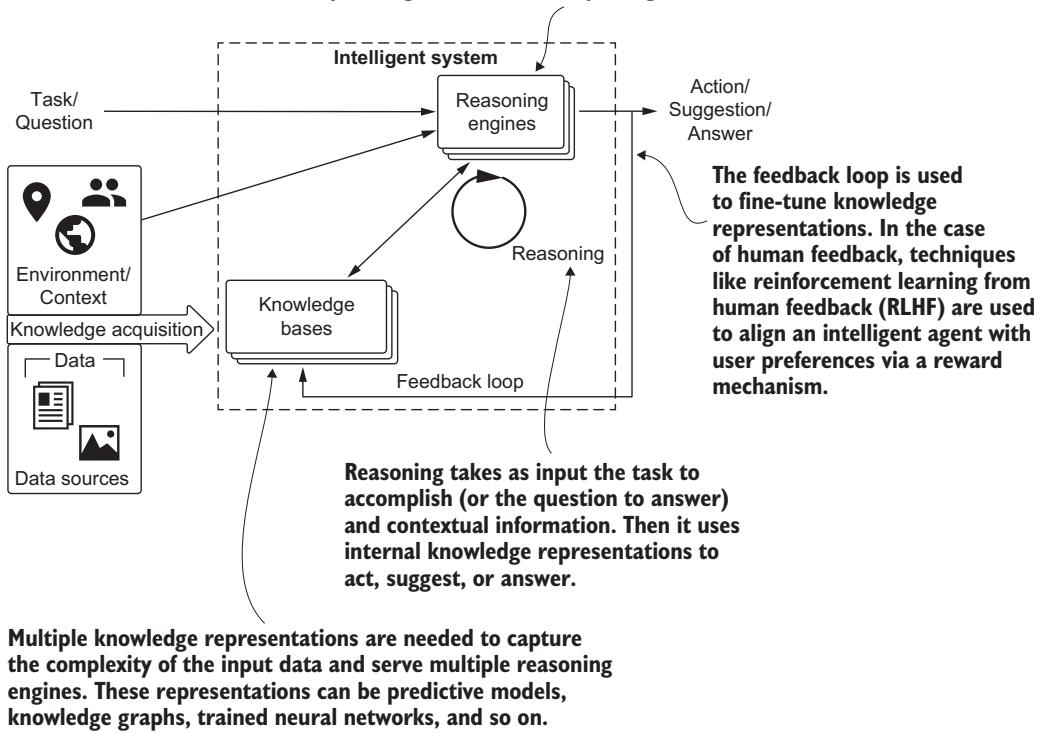

*그림 2.1 — 지능형 시스템의 고수준 도식. **지식 베이스(knowledge base)** 와 **추론 엔진(reasoning engine)** 이라는 두 가지 구성 요소 유형으로 이루어지고, 각 유형은 시스템이 수행할 과제에 따라 여러 인스턴스를 가질 수 있다. 이 그림이 이 장 전체를 관통하는 멘탈 모델이고, 아래 그림 2.4·2.8·2.10 은 모두 이 그림을 한 겹씩 확장한 것이다.*

그림에서 읽어야 할 것은 상자 두 개가 아니라 **"여러 개"** 라는 점이다. 한 에이전트 안에 지식 베이스도 추론 엔진도 여럿 있을 수 있고, 이들은 순차적으로도 병렬적으로도 상호작용한다. 같은 지식 표현이 여러 추론 엔진에 쓰일 수도 있고, 모델들 사이의 소통 방식으로 쓰일 수도 있다. 한 과정의 출력이 다른 과정의 입력이 되어 **지식이 점점 정교해지는 순환 고리** 를 만든다. 이 순환이 2.5 절의 피드백 루프이고, 15장의 LangGraph 에이전트는 이 순환을 코드로 구현한 것이다.

### 설계자가 계속 마주칠 상충 관계

| 축 | 한쪽 끝 | 다른 쪽 끝 |
| --- | --- | --- |
| 표현력 vs 처리 효율 | 표현력이 풍부할수록 담을 수 있는 의미가 많다 | 표현력이 커질수록 처리 비용이 커진다 |
| 일반성 vs 적합성 | 범용 표현은 재사용된다 | 효과적인 표현은 도메인·과제마다 다르다 |

게다가 지식 표현과 추론은 **서로 얽혀 있다.** 어떻게 표현하느냐가 어떤 추론이 가능한지를 정하고, 어떤 추론을 하고 싶은지가 어떻게 표현해야 하는지를 정한다. 그래서 이 둘을 따로 최적화할 수 없다.

이 책의 핵심 주장이 여기서 나온다. **KG 는 지식을 효율적으로 표현하고, 새로운 통찰을 이끌어내며, 정밀하고 효과적인 추론의 토대를 놓는 근본 데이터 구조** 라는 것이다. 그리고 KG 를 LLM 과 함께 쓰면 데이터 소스를 지식으로 바꾸는 일도, 과제를 해석하고 사용자에게 답을 주는 일도 한결 수월해진다.

이 장에서 설계할 기본적인 지능형 시스템은 세 가지를 할 수 있어야 한다.

- 지식을 수집하고 효과적으로 **표현** 하기 → 2.3 절

- 그 지식을 사용해 자율적으로 **추론** 하기 → 2.4·2.5 절

- 질문에 답하고 정보에 근거한 **의사결정을 지원** 하기 → 2.2·2.6 절


---
### 2.2 지능형 시스템 설계하기 — 의료 진단 시나리오로 구조 잡기

2.1 절이 부품을 정의했다면, 2.2 절은 **그 부품으로 무엇을 지을지** 를 좁힌다. 좁히는 도구가 구체적 시나리오다.

> **과제** — 여러분이 **자율 의료 진단 시스템** 을 만들라는 임무를 받았다. 이 시스템은 의사가 질병을 진단하고 환자를 치료하기 위해 일련의 조치(질문·의학 검사·치료법)를 고르도록 돕는다.

왜 하필 의료인가. 이 도메인이 **전역적·일반적 지식** (의학 문헌 전체)과 **특정 맥락의 정보** (이 환자의 기록)를 반드시 함께 써야 하는 문제이기 때문이다. 둘 중 하나만으로는 답이 안 나온다. 그리고 이 구조는 3장(희귀 질환 진단)·4장(약물 재활용)·13장(KG 기반 RAG)에서 계속 재사용된다.

또 하나의 전제가 있다. **머신러닝의 힘을 온전히 끌어내려면 알고리즘 하나가 아니라 알고리즘과 도구들의 "시스템"을 지어야 한다** — 한 알고리즘의 출력이 다른 알고리즘의 입력이 되거나, 둘의 출력이 결합되는 시스템이다. 이 책이 파이프라인을 강조하는 이유가 여기 있다.

#### 2.2.1 지능형 시스템이란 무엇인가? — 사용자를 돕고 스스로 진화하는 시스템

저자들은 Geoff Hulten 의 정의를 택한다.

> **정의** **지능형 시스템(intelligent system)** 은 사용자를 AI 및 ML 과 연결하여 의미 있는 목표를 달성하게 하는 시스템이다. 시간이 지남에 따라 그 지능이 진화하고 향상되는 시스템, 특히 **사용자가 시스템과 어떻게 상호작용하는지를 관찰함으로써 스스로 개선되는** 시스템을 말한다.

이 정의에서 두 가지를 짚어야 한다.

첫째, **사용자가 정의 안에 들어 있다.** 일차 목표는 사용자를 대체하는 것이 아니라 사용자가 복잡한 과제를 완수하도록 돕는 것이다. 자율 의료 진단 시스템은 의사의 전문성을 대체하려는 것이 아니라 의사가 정보에 근거한 결정을 내리도록 보조한다. 자율주행차처럼 사용자와 무관하게 스스로 작동하는 시스템과 대비된다.

둘째, **진화가 정의 안에 들어 있다.** 한 번 만들고 끝나는 모델은 이 정의로는 지능형 시스템이 아니다. 시스템은 진화하는 지식 베이스를 끊임없이 발전시키고, 사용하고, 유지해야 하며, 그 진화는 데이터 소스뿐 아니라 **사용자와의 지속적 상호작용** 으로도 추동된다.

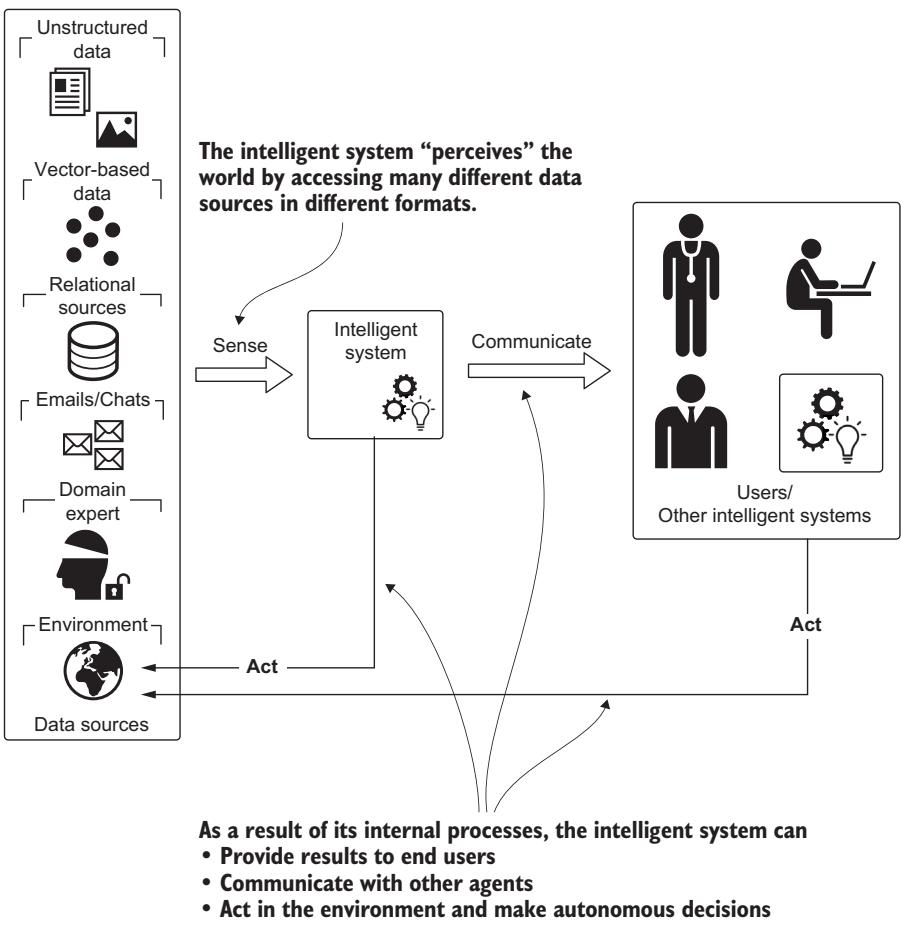

*그림 2.2 — 아직 내부를 열지 않은 블랙박스로서의 지능형 시스템과 그 주변. 환경을 관찰하고 기존 소스로부터 데이터를 받아 지식을 습득하며, 내부 과정을 거쳐 최종 사용자에게 결과를 제공한다. 이 그림의 화살표 중 "환경 관찰 → 지식"과 "사용자 피드백 → 지식"이 2.5 절 피드백 루프의 씨앗이다.*

#### 2.2.2 지능형 시스템의 분류 — 자율 시스템과 자문 시스템

"사용자를 **지원** 하는가, 사용자를 **대신해 행동** 하는가"라는 한 가지 질문이 지능형 시스템을 두 범주로 가른다.

| | **지능형 자율 시스템** (autonomous) | **지능형 자문 시스템** (IAS, advisory) |
| --- | --- | --- |
| 역할 | 과제를 독립적으로 수행하고 실행까지 한다 | 정보와 권고를 제공한다 |
| 특징 1 | **완전 자동화** — 사람 입력 없이(또는 최소로) 프로그래밍과 센서 데이터로 결정 | **의사결정 지원** — 통찰·제안·권고를 주되 조치를 실행하지 않는다 |
| 특징 2 | **실시간 의사결정** — 데이터를 분석해 실시간으로 판단 | **맥락 인식** — 사용자 선호·시나리오 같은 맥락으로 조언을 조정 |
| 특징 3 | **적응성** — 변화하는 환경과 예기치 못한 상황에 적응 | **사용자 상호작용** — 선택지 탐색·질문·상세 설명이 쉬워야 한다 |
| 예 | 자율주행차 | 예측 치안, 사기 탐지, 진단 보조 |

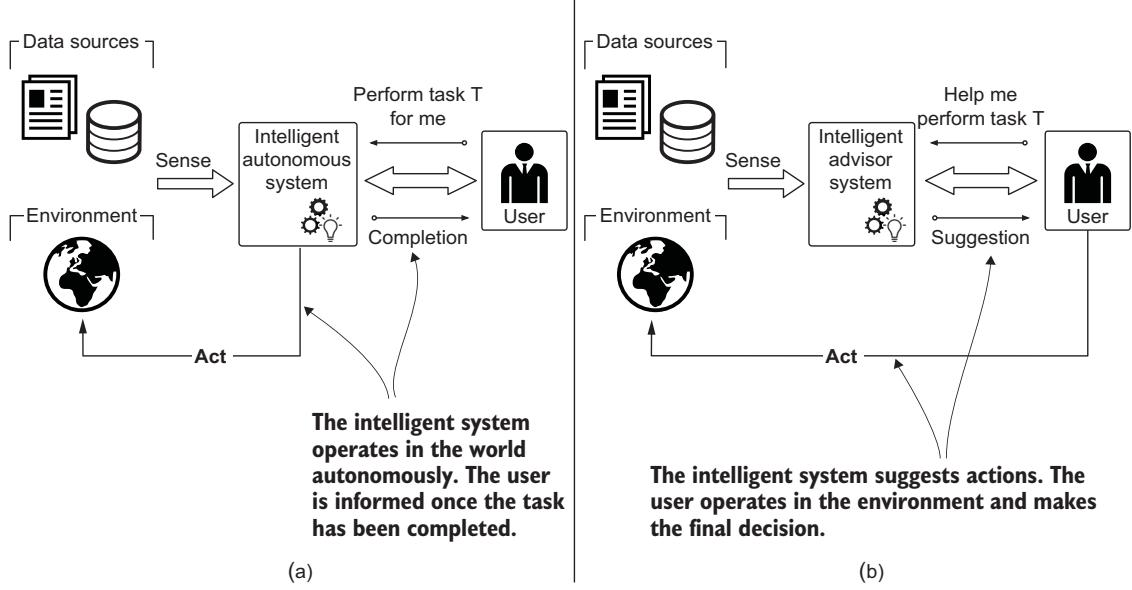

*그림 2.3 — (a) 지능형 자율 시스템과 (b) 지능형 자문 시스템의 차이. 앞의 것은 사용자를 대신해 행동하고, 뒤의 것은 제안만 한다. **두 경우 모두 목표는 최종 사용자를 지원하거나 돕는 것이지 대체하는 것이 아니다.** 아래에서 이 책이 (b) 를 택하는 이유가 나온다.*

**이 책은 IAS 에 초점을 둔다.** 취향의 문제가 아니라 기술적 정합성의 문제다. IAS 가 요구하는 세 가지 — 강화된 의사결정 지원, 깊은 맥락 인식, 상호작용적 사용자 경험 — 가 KG 의 강점과 정확히 겹치기 때문이다. KG 는 근거를 되짚을 수 있고(지원), 노드 주변의 관계로 맥락을 표현하며(맥락), 질의로 탐색할 수 있다(상호작용).

IAS 의 사례는 여러 분야에 있다.

| 분야 | 사례 |
| --- | --- |
| **법 집행** | 예측 치안(predictive policing) — 범죄 데이터를 분석해 우범 지역을 식별 |
| **금융 서비스** | 거래 패턴을 분석해 사기를 시사하는 의심 활동에 표시 (10장 사기 탐지가 이 사례다) |
| **생의학** | 가능한 진단 목록을 제시하고 데이터에 근거해 치료 선택지를 권고 (3·4장) |

이 모든 경우에 공통된 것은 하나다. **어떤 조치를 취할지에 대한 최종 결정은 그것을 사용하는 사람이 내린다.** 4장 노트북이 임상 프롬프트(책 4.23)를 원문만 싣고 실행하지 않는 것도 이 원칙을 그대로 따른 것이다.

#### 2.2.3 지능형 시스템의 특성 — 설계를 이끄는 네 가지 축

| 특성 | 뜻 | 설계에 주는 제약 |
| --- | --- | --- |
| **의미 있는 목표** | 최종 사용자에게 의미 있는 구체적·달성 가능한 목적 | 이 목표가 개발 과정 **전체** 를 이끌어야 한다 → 2.6 절 목적 주도 접근의 근거 |
| **지능적 경험** | 지능적 출력을 원하는 성과로 이어지게 제시하는 인터페이스 | 예측에 따라 적응해야 한다. **맞았을 때 가치를 극대화하고 틀렸을 때 비용을 최소화** 하며, 암묵적·명시적 피드백을 원활히 받아야 한다 |
| **지식 생성과 갱신** | 지식을 지속적으로 구축·유지하고 그것으로 추론하는 능력 | LLM+KG 결합이 진화하는 지식과 사용자 피드백을 다루는 자리 |
| **오케스트레이션** | 여러 알고리즘·도구가 서로의 입출력을 주고받으며 함께 작동 | 지식 습득 방식을 관리하고, 위험을 통제하고, 생애 주기 전체의 품질을 유지 |

"지능적 경험"의 정의가 특히 중요하다. **틀릴 것을 전제로 인터페이스를 설계하라** 는 말이기 때문이다. 확률적 부품을 쓰는 이상 오류는 사라지지 않으므로, 남는 설계 변수는 "오류가 났을 때 사용자가 치르는 비용"뿐이다. 이 관점이 2.4 절에서 LLM 의 추론 실패를 다루는 방식과 이어진다.

이 네 특성에서 저자들은 **세 가지 아키텍처 결정** 을 끌어낸다. 이 세 줄이 이 책 나머지 전체의 전제다.

| 결정 | 내용 | 반대편을 버리는 이유 |
| --- | --- | --- |
| **자율 자문 시스템에 집중한다** | 조치를 대신 완수하지 않고 **제안** 한다 | 고위험 도메인에서 실행 권한을 넘기면 오류 비용이 사람에게 전가된다 |
| **정립된 지식 베이스를 사용한다** | 일반 상식이 아니라 **연구 논문·기존 온톨로지·구조화된 데이터 소스** | 뭉뚱그린 일반적 답 대신 전문가가 다듬은 도메인 특화 이해를 써야 한다 |
| **경험에서 배운다** | 제안한 조치의 **결과 피드백** 으로 지식 베이스를 확장한다 | 정적인 지식 베이스는 위 정의상 지능형 시스템이 아니다 |

두 번째 결정이 3장에서 HPO 온톨로지를, 4장에서 Hetionet·CKG 를 쓰는 직접적인 이유다.

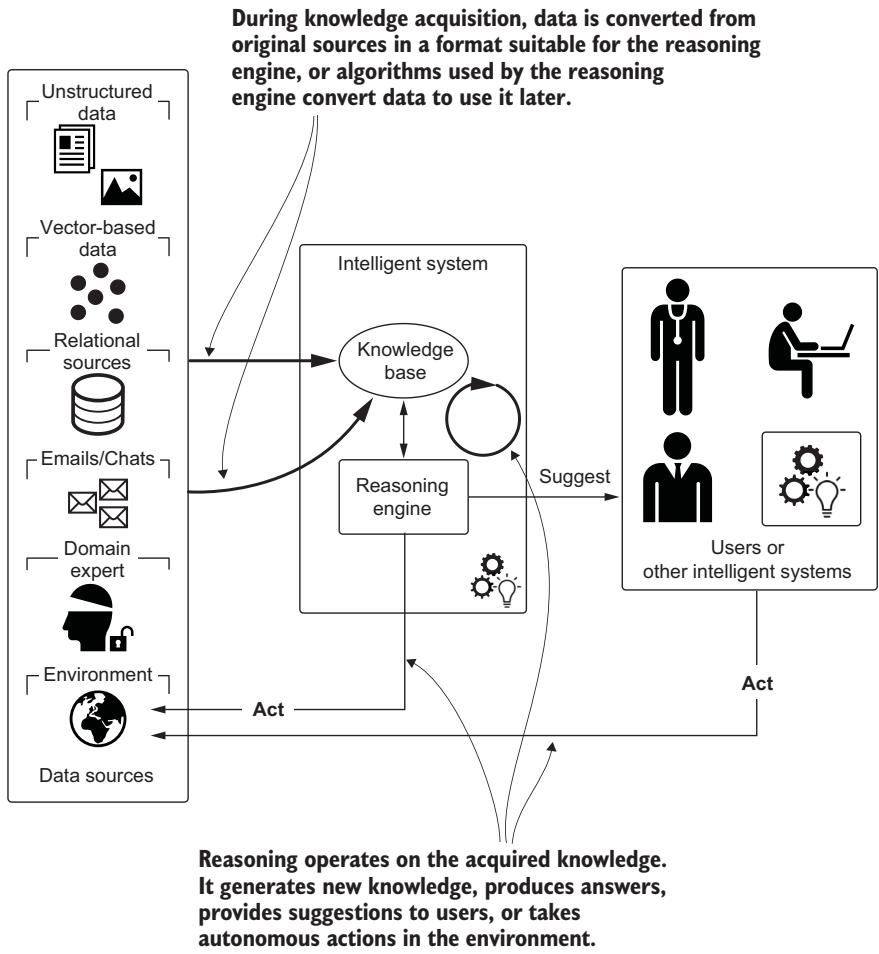

*그림 2.4 — 지능형 시스템의 확장 모델. 그림 2.1 의 두 **구성 요소**(지식 베이스·추론 엔진)에 두 **핵심 과정**(지식 습득·추론)을 덧붙였다. 이어지는 2.3 절이 왼쪽의 지식 습득을, 2.4\~2.5 절이 오른쪽의 추론을 하나씩 확대한다.*

이제 남은 것은 두 과정이다.

- **지식 습득(knowledge acquisition)** — 데이터 소스·환경·도메인 전문가로부터 정보를 수집하는 것 → 2.3 절

- **추론(reasoning)** — 습득한 지식을 실행 가능한 전문성으로 변환하는 것 → 2.4·2.5 절


---
### 2.3 지식 습득과 표현 — KG와 LLM이 갈라지는 지점

**지식 습득** 은 IAS 가 배치될 도메인의 데이터로부터, 그리고 사용자 피드백과 환경으로부터 "배울" 수 있게 해 주는 과정이다. 하는 일은 한 문장으로 정리된다. **원시 데이터(raw data)를 시스템 요구사항에 맞게 다듬어진 구조화된 지식 표현으로 변환하고, 그 결과를 하나 이상의 지식 베이스에 저장한다.**

여기서 이 장의 결정적인 문장이 나온다. **지식을 어떻게 습득·표현·저장하는가는 그 밑에 깔린 추론 메커니즘에 따라 달라진다.** 즉 습득 방식을 먼저 고르고 추론을 나중에 정할 수 없다. 그리고 바로 이 지점에서 KG 와 LLM 이 크게 갈라진다.

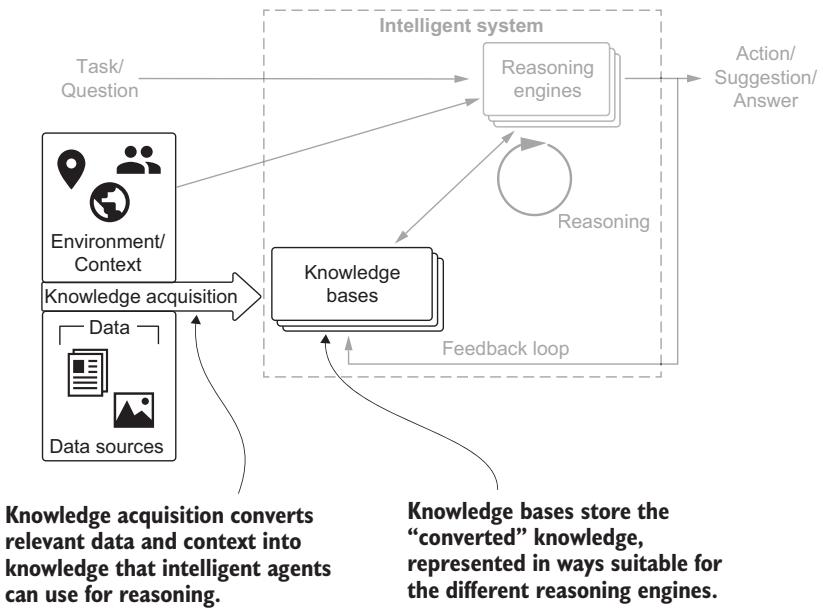

*그림 2.5 — 그림 2.4 의 확장 모델에서 이 절이 확대하는 부분. 지능형 시스템이 데이터를 습득해 지식으로 변환하는 경로다. 아래 그림 2.6·2.7 이 이 상자 안을 KG 방식과 LLM 방식으로 각각 열어 본다.*

#### KG 의 습득 — 명시적 구조로 옮기고, 사람이 함께 판단한다

KG 에서 지식 습득은 대개 원시·구조화·반구조화 데이터를 **그래프 기반 형식** 으로 변환하는 일이다. **개체(entity)** 는 노드가 되고 개체 사이의 관계는 간선이 된다.

이 변환을 이끄는 것이 **온톨로지나 스키마로 정의되는 도메인의 구조와 의미론(semantics)** 이다. 그리고 이 과정에는 흔히 **도메인 전문가** 가 참여해 데이터의 의미와 개체 사이의 내재적 관계를 이해하도록 돕는다. 이질적 소스들을 하나의 통일된 명시적 스키마로 옮기려면 결과 KG 가 도메인을 정확히 반영하도록 꼼꼼한 작업이 필요하다.

이 비용은 그냥 비용이 아니다. **유연성이라는 형태로 값을 치른다** 는 것이 저자들의 표현이다. 3장에서 HPO 온톨로지를 기준 어휘로 삼아 서로 다른 두 형식의 소스를 합치는 작업이 이 문장의 실물이다.

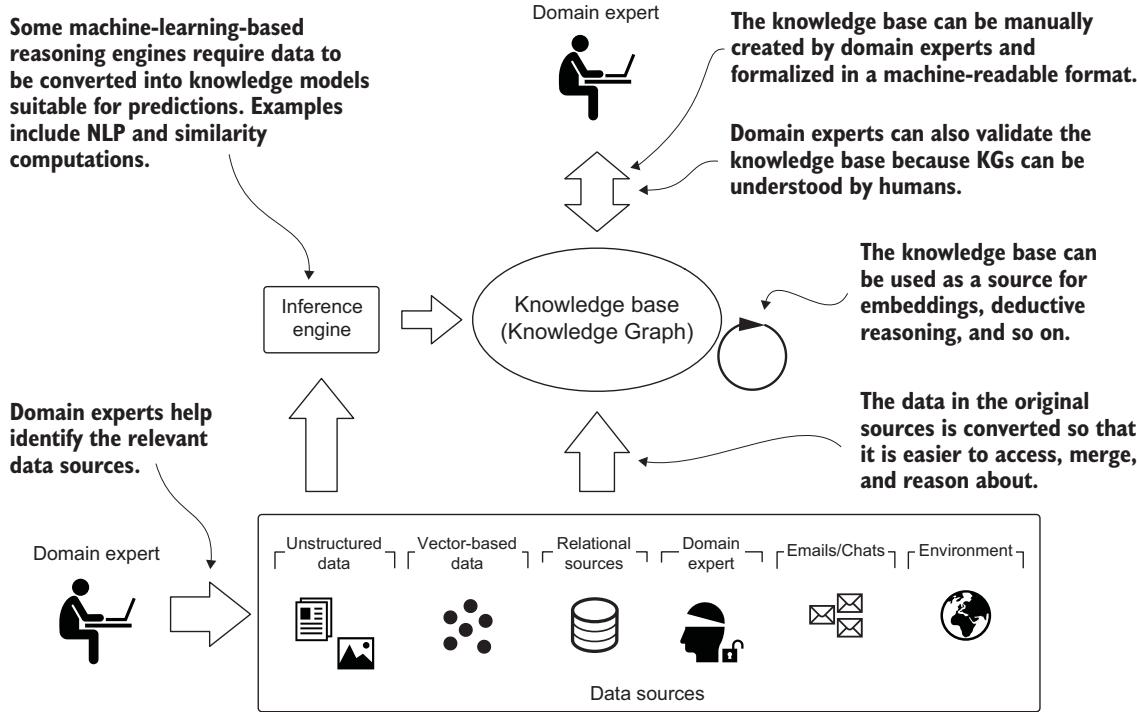

*그림 2.6 — KG 를 위한 지식 습득. 확보된 데이터를 구조화된 개체·관계·속성을 통해 **명시적** 지식 표현으로 변환한다. 도메인 전문가가 관련 데이터 소스를 식별하고, 데이터 모델을 뒷받침하며, 결과를 평가하는 **세 지점 모두** 에 참여한다.*

#### LLM 의 습득 — 통계적 패턴으로 눌러 담고, 들여다볼 수 없다

LLM 은 방대한 비구조화 텍스트를 받아들여 지식을 습득한다. 이 데이터는 학습 과정에서 **조밀한 고차원 벡터 공간** 으로 부호화된다. 다루는 데이터 양이 워낙 크다는 점을 감안하면 KG 만큼의 광범위한 데이터 준비를 요구하지 않고, 과정 대부분이 **비지도(unsupervised)** 다. 주된 노력은 데이터 소스를 고르고 정제하는 데 들어간다.

정보는 스키마로 정의된 명시적 관계가 아니라 **통계적 패턴** 으로 부호화된다. 이 암묵적 방식 덕분에 LLM 은 미묘한 맥락적 의미와 복잡한 언어적 관계를 포착하지만, **대신 지식이 불투명해져 들여다보거나 수정하기 어렵다.** 2.4 절에서 볼 추론 실패가 왜 진단하기 어려운지도 여기서 설명된다 — 틀린 답이 어느 파라미터에서 왔는지 짚을 수 없다.

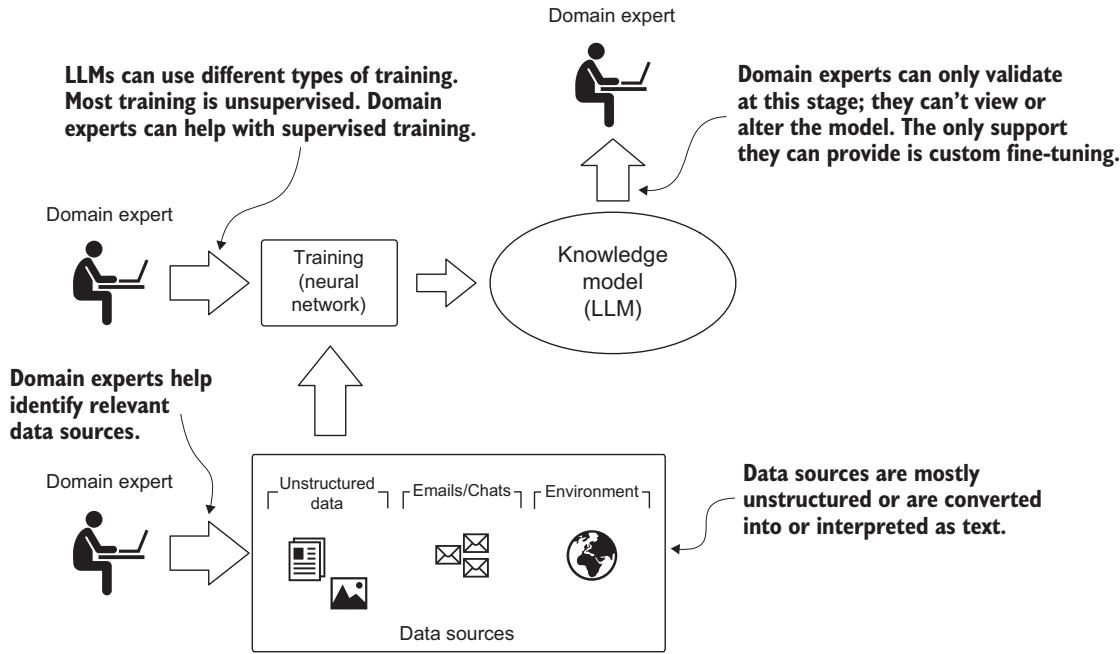

*그림 2.7 — LLM 을 위한 지식 습득. 텍스트 데이터를 **통계적 매개변수** 를 통해 **암묵적** 지식 표현으로 변환한다. 그림 2.6 과 비교하면 차이가 한눈에 보인다 — 도메인 전문가는 **데이터 소스 선택** 과 **결과 평가** 단계에만 참여하고, 변환 자체에는 개입할 자리가 없다.*

#### 두 방식을 나란히 놓기

저자들이 꼽은 세 가지 핵심 차이다. 두 기술을 함께 쓰는 시스템을 설계할 때 반드시 고려해야 한다.

| 축 | LLM | KG |
| --- | --- | --- |
| **접근성 (Access)** | 연속적 벡터 공간 속 수십억 매개변수를 이용한 **암묵적** 표현. 불투명하고 사람이 접근하기 어렵다 | 노드·관계·속성을 통한 **명시적** 표현. 사람과 기계 모두 직접 해석할 수 있다 |
| **갱신 (Updates)** | 재학습 또는 미세 조정(fine-tuning)이 필요하다 | 노드와 관계를 추가·삭제·수정하면 된다 |
| **능력 (Capabilities)** | 본질적으로 사람의 언어를 이해하고 생성하는 데 능하다 | 개발자가 접근 패턴과 도메인 스키마를 어떻게 설계하느냐에 크게 좌우된다 |

표를 세로로 읽으면 두 기술의 우열이 보이지 않는다. **가로로 읽어야 한다.** 세 축 모두에서 강점이 정확히 반대편에 있다. LLM 이 약한 곳(접근성·갱신)에서 KG 가 강하고, KG 가 개발자 역량에 의존하는 곳에서 LLM 은 별도 설계 없이도 언어를 다룬다.

그래서 저자들의 결론은 "둘 중 무엇을 고를까"가 아니다. **차이가 곧 상호 보완성** 이므로, 하이브리드 접근법을 쓰면 양쪽의 한계를 넘고 서로에게 힘을 실어 줄 수 있다는 것이다.

이 전환은 "추론"이라는 말의 뜻도 넓힌다. 추론은 더 이상 형식적 추론 메커니즘에 갇히지 않고 **확률적·맥락적·패턴 기반 계산** 까지 포함하게 된다. 덕분에 AI 시스템은 전통적 전문가 시스템처럼 명시적·구조화된 지식으로 추론하는 **동시에**, 언어와 경험에서 나온 비구조화·모호·맥락적 지식으로도 추론할 수 있다. 다음 절이 이 확장된 추론을 다룬다.


---
### 2.4 추론 — 불확실성·추론·일반화라는 세 가지 열린 질문

IAS 에서 **추론 엔진** 은 통찰과 제안을 전달하는 부품이다. 사용자는 원하는 목표와 필요한 추가 정보를 담은 요청으로 입력을 준다.

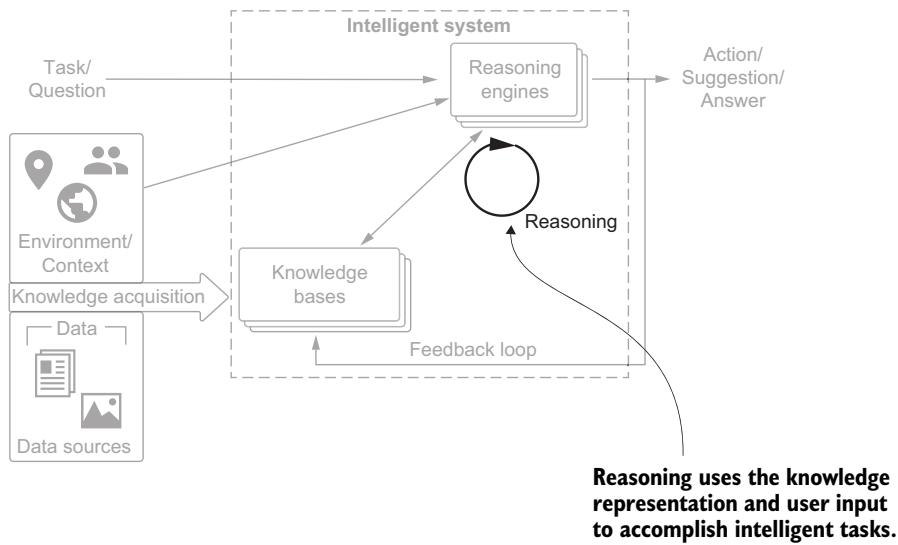

*그림 2.8 — 그림 2.4 의 확장 모델에서 이 절이 확대하는 부분. 추론은 **하나 이상의** 지식 베이스를 사용해, 지능형 시스템이 최종 사용자를 위해 수행하도록 설계된 과제들을 완수한다. 2.3 절이 왼쪽(습득)이었다면 여기는 오른쪽이다.*

이 부품을 설계하기 전에 답해야 할 **열린 질문 세 가지** 가 있다. "열린"이라고 부른 이유는 완결된 해법이 없기 때문이고, 그래서 이 세 질문이 이 책 나머지의 과제 목록이 된다.

| 열린 질문 | 무엇이 문제인가 | 이 책에서 다루는 곳 |
| --- | --- | --- |
| **불확실성을 어떻게 다룰 것인가?** | 가진 정보가 모두 참·정확·명료하지 않다. 추론의 정확도는 처음 진술들이 얼마나 확실한가에 달려 있다 | 2.5.3 절(LLM 의 확률적 추론), 7\~8장(개체 명확화) |
| **필요한 지식 중 일부를 어떻게 추론해낼 것인가?** | 어떤 상황에서는 확보된 데이터로부터 새 정보를 이끌어낼 수 있다 | 3장(온톨로지 기반 추론), 12장(링크 예측) |
| **본 것으로부터 어떻게 도메인에 대한 더 넓은 이해로 추상화할 것인가?** | 개별 사례를 넘어서는 일반화가 필요하다 | 9\~11장(그래프 ML·표현 학습) |

#### 왜 "외우기"는 학습이 아닌가 — 스팸 필터 예시

세 번째 질문을 설명하기 위해 저자들은 *Graph-Powered Machine Learning* 에서 이메일 스팸 필터 예시를 가져온다.

순수한 프로그래밍 방식의 해법은 이렇다. 사용자가 스팸으로 표시한 모든 이메일을 그대로 외워 지식 베이스에 저장한다. 새 이메일이 오면 지식 베이스에서 일치하는 항목을 찾는다. 일치하면 스팸 폴더로 보내고, 아니면 통과시킨다.

이 방식은 **작동한다.** 어떤 시나리오에서는 유용하기까지 하다. 그런데도 저자들은 이것이 제대로 된 학습 과정이 아니라고 잘라 말한다. 이유는 하나다. **일반화하는 능력** — 개별 사례들을 더 넓은 모델로 변환하는 능력 — 이 없기 때문이다. 이 사례에서 그것은 "이전에 표시된 이메일과 똑같지 않더라도 처음 보는 이메일에 라벨을 붙일 수 있는 능력"을 뜻한다. 이 과정을 **귀납적 추론(inductive reasoning)** 이라 부른다.

이 예시는 이 장 전체에서 두 번 쓰인다. 지금은 "일반화가 없으면 학습이 아니다"를 보이는 데 쓰이고, 뒤에서는 그 반대 방향 — **일반화가 지나치면 틀린다** — 를 보이는 데 쓰인다.

#### 연역적 추론과 귀납적 추론 — 확실한 결론 대 위험한 일반화

| | **연역적 추론 (deductive)** | **귀납적 추론 (inductive)** |
| --- | --- | --- |
| 방향 | 일반적 진술·가설 → 구체적 결론 | 구체적 관찰 → 폭넓은 일반화 |
| 예 | "모든 사람은 죽는다. Alessandro 는 사람이다. 따라서 Alessandro 는 죽는다." | "주머니에서 꺼낸 첫·둘째·셋째 동전이 모두 페니다. 따라서 주머니 안의 모든 동전은 페니다." |
| 전제가 참이면 | 결론도 **반드시** 참이다 | 결론이 **거짓일 수 있다** |
| 실패 예 | (전제가 거짓일 때만 실패한다) | "Harold 는 할아버지다. Harold 는 대머리다. 따라서 모든 할아버지는 대머리다." |
| 필요한 것 | 완전하고 정확한 지식 베이스 | 대표성 있는 표본 |

귀납의 결론이 거짓일 수 있다는 것은 결함이 아니라 **정의상의 대가** 다. 아직 보지 못한 것에 대해 말하려면 논리적 보증을 포기해야 한다. 이 대가를 어떻게 관리하느냐가 2.5 절의 주제다.

#### LLM 은 정말 추론하는가 — 리스팅 2.1 의 설계

ChatGPT 같은 도구가 사람의 대화를 흉내 내다 보니 사람들은 흔히 이들이 폭넓은 추론 능력을 지녔다고 생각한다. 저자들은 이 가정을 검증하기 위해 LLM 기반 "추론" 도구 중 하나인 **Claude.ai** (`https://claude.ai`) 를 골라 프롬프트 하나를 던졌다. 그것이 이 장 유일한 리스팅인 **책 Listing 2.1** 이다.

> **참고** 저자들이 테스트한 버전은 **Claude 3.5 Sonnet** 이다. 저자들 스스로 "개선 속도를 감안하면 이 책이 인쇄될 무렵 같은 실험을 돌리면 다른 결과가 나오리라고 거의 확신한다"고 적었다.

**이 프롬프트가 왜 이렇게 생겼는지** 를 먼저 알아야 결과를 읽을 수 있다. 널리 알려진 강 건너기 퍼즐은 농부가 **늑대·양·양배추** 를 옮기는 문제다. 배에 하나씩만 실을 수 있고, 늑대와 양을 남기면 양이 잡아먹히고 양과 양배추를 남기면 양배추가 먹히므로 왕복이 여러 번 필요하다. 저자들은 여기서 **늑대와 양배추를 빼 버렸다.** 남은 것은 농부와 양뿐이라 답은 자명하다 — 태우고 한 번 건너면 끝이다.

이 축약이 함정인 이유는 이렇다.

| 조건 | 결과 |
| --- | --- |
| 원래 퍼즐이 학습 데이터에 **많이** 들어 있다 | 모델은 그 풀이 절차를 강하게 기억한다 |
| 변형이 원문과 **비슷하지만 같지는 않다** | 표면적 유사성이 원래 절차를 불러낸다 |
| 변형의 정답이 원문의 정답과 **완전히 다르다** | 절차를 불러오면 반드시 틀린다 |

즉 이 프롬프트는 **문제를 읽고 푸는 것** 과 **비슷한 문제의 풀이를 재생하는 것** 을 분리해 내도록 설계된 리트머스 시험지다. 저자들의 예상은 명확했다. 확률적 추론 엔진이 실제로 물은 것을 "이해"하기보다 늑대·양배추가 있는 완전한 문제 쪽으로 방향을 틀리라는 것. 아래 셀에서 프롬프트 원문을 그대로 확인한다.


In [3]:
"""책 Listing 2.1 — 추론 능력을 확인하기 위한 프롬프트 (농부와 양).

이 리스팅은 "실행해서 그래프를 만드는" 코드가 아니라 **LLM 에 넣는 영어 프롬프트
텍스트** 다. 그래서 이 셀이 기본적으로 하는 일은 원문을 그대로 보여주는 것뿐이고,
실제 API 호출은 RUN_LLM 가드 뒤에 둔다. 이유가 셋이다.

  1) 이 장을 이해하는 데 호출이 필요 없다. 책이 관찰한 결과는 그림 2.9 에 있다.
  2) API 키가 없는 스터디원도 노트북을 끝까지 완주할 수 있어야 한다.
  3) 답이 모델·시점마다 달라지므로, 한 번의 출력을 노트북에 박아 두면
     그것이 "정답"처럼 읽힌다. 이 리스팅의 요점은 특정 출력이 아니라 실패의 **유형** 이다.

파일 이름에 주의. 이 원문은 listings/'2.3 - Prompt for checking reasoning capabilities'
에 있다. 저장소의 '2.1 - ChatGPT example Prompt' 가 아니다 — 그 파일은 책에 대응
리스팅이 없다(바로 아래에서 함께 확인한다). show() 가 study.toml 의 대응표를 거치므로
파일 이름을 직접 쓰지 않는다.
"""
show("2.1")

print("\n" + "=" * 78)
print("이 프롬프트의 정답: 농부가 양을 배에 태우고 한 번 건너면 끝난다. 1회.")
print("원래 퍼즐(늑대·양·양배추)의 정답은 여러 번의 왕복이다. 두 답은 겹치지 않는다.")
print("=" * 78)

if RUN_LLM:
    print("\nRUN_LLM = True — 실제 엔드포인트에 프롬프트를 던진다.\n")
    answer = ask_llm("2.1")
    print("-" * 78)
    print(answer)
    print("-" * 78)
    print("\n확인할 것: 왕복이 2회 이상 나오는가? 늑대나 양배추가 등장하는가?")
    print("             둘 중 하나라도 나오면 책이 관찰한 실패 유형이 재현된 것이다.")
else:
    print("\nRUN_LLM = False — API 를 호출하지 않는다. 책이 관찰한 결과는 아래 그림 2.9 에 있다.")
    print("직접 확인하려면 위 환경 점검 셀에서 RUN_LLM = True 로 바꾸고 두 셀을 다시 실행하라.")
    print("(설정은 study.toml 의 [llm].env_file 이 가리키는 저장소 밖 파일에서 읽는다.)")

# 참고: 책에 대응 리스팅이 없는 MEAP 잔여 파일. 스터디원이 listings/ 를 열었을 때
# '2.1' 로 시작하는 파일이 있는데 왜 안 쓰는지 의아해하지 않도록 여기서 함께 보여 준다.
orphan = cypher.find("2.1 - ChatGPT", HERE / "listings")
print("\n" + "=" * 78)
print(f"[참고] 책에 대응 리스팅이 없는 파일: listings/{orphan.name}")
print("=" * 78)
print(orphan.read_text(encoding="utf-8").strip())


── 책 Listing 2.1 Prompt for checking reasoning capabilities ──
   (파일: listings/2.3 - Prompt for checking reasoning capabilities)

A farmer stands at the side of the river with a sheep. There is a boat with enough room for one person and one animal. How can the farmer get himself and the sheep to the other side of the river using the boat in the smallest number of trips?

이 프롬프트의 정답: 농부가 양을 배에 태우고 한 번 건너면 끝난다. 1회.
원래 퍼즐(늑대·양·양배추)의 정답은 여러 번의 왕복이다. 두 답은 겹치지 않는다.

RUN_LLM = False — API 를 호출하지 않는다. 책이 관찰한 결과는 아래 그림 2.9 에 있다.
직접 확인하려면 위 환경 점검 셀에서 RUN_LLM = True 로 바꾸고 두 셀을 다시 실행하라.
(설정은 study.toml 의 [llm].env_file 이 가리키는 저장소 밖 파일에서 읽는다.)

[참고] 책에 대응 리스팅이 없는 파일: listings/2.1 - ChatGPT example Prompt
You are a virtual doctor, and you have a patient reporting the following symptoms, what would you recommend?
"I have had a strong headache for a few days and often I forget things that I've done. Sometimes I have some issues in speaking properly"


#### 결과 — 확률적으로 가장 가까운 답으로 미끄러진다

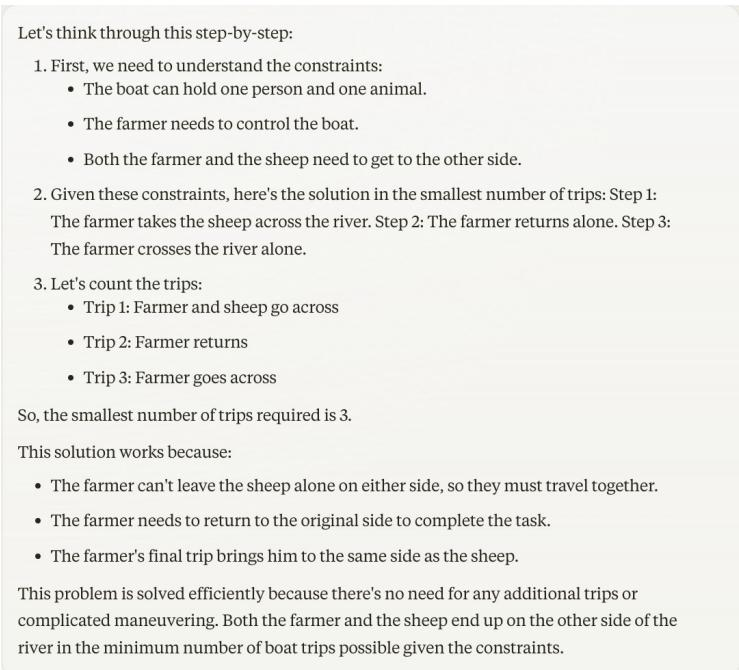

*그림 2.9 — 리스팅 2.1 의 내용을 프롬프트로 입력했을 때 Claude.ai(3.5 Sonnet)가 내놓은 결과 캡처. 위 코드 셀에서 확인한 프롬프트의 정답은 "1회"인데, 답변은 농부가 강을 여러 번 오가는 절차를 제시한다. 이 그림 한 장이 이 장에서 KG 가 필요한 이유의 실증이다.*

저자들이 지적한 문제는 이것이다. **농부가 양 없이 강을 왔다 갔다 하는 것은 아무 의미가 없다.** 문제는 1단계 이후에 이미 완전히 풀렸다. 그런데도 답변이 이어지는 이유는, 문제 서술이 학습 데이터 속 원래 퍼즐과 **매우 비슷하지만 똑같지는 않아서**, 제안된 해법이 "확률적으로" 가장 가까운 쪽으로 흘러갔기 때문이다.

여기서 2.4 절 앞부분의 스팸 필터 예시가 반대 방향으로 다시 등장한다.

| | 스팸 필터의 실패 | 리스팅 2.1 의 실패 |
| --- | --- | --- |
| 무엇이 문제인가 | 외우기만 하고 **일반화하지 못한다** | 표면적 유사성으로 **과하게 일반화한다** |
| 처음 보는 입력에 | 아무 판단도 못 한다 | 익숙한 절차를 그대로 적용한다 |
| 겉보기 | 명백히 무능해 보인다 | **유창하고 조리 있어 보인다** |

마지막 행이 실무에서 중요하다. 첫 번째 실패는 눈에 띄지만 **두 번째 실패는 눈에 띄지 않는다.** 답변이 단계별로 정연하게 서술되어 있어서, 문제를 이미 알고 있는 사람이 아니면 틀렸다는 사실 자체를 알아채기 어렵다. 2.2.3 절의 "지능적 경험" — 틀렸을 때의 비용을 최소화하는 인터페이스 — 이 왜 설계 특성으로 명시되었는지가 여기서 드러난다.

#### 일화가 아니라 측정된 현상이다

이 관찰이 운 나쁜 한 번의 사례가 아니라는 근거로 저자들은 **Wu 등** 의 연구를 인용한다. 이들은 코딩·그림 그리기·논리·공간 추론·체스·산술에 이르는 **서로 다른 11개 과제** 를 묶어 테스트했다. 각 과제마다 기본 조건과 **반사실적(counterfactual) 변형** — 기본값이나 잘 알려진 설정에서 벗어난 경우, 이를테면 늑대와 양배추가 빠진 농부와 양 문제 같은 것 — 을 함께 돌렸다.

결과는 이렇다. 변형에서도 흥미로운 수준의 성능이 나오긴 했지만, 기본 조건 대비 **상당하고 일관된 성능 저하** 가 관찰됐다. 저자들이 끌어낸 결론은 신중하다. 현재의 LLM 이 어느 정도 추상적 과제 해결 능력을 지니고 있는 것은 맞지만, **흔히 좁고 전이되지 않는 절차에 의존한다.**

#### 그래서 어디에 무엇을 쓰는가

| 과제의 성격 | 적합한 쪽 |
| --- | --- |
| 정밀하고 규칙 기반의 추론, 명시적 지식 표현이 필요 | **KG** |
| 패턴 인식, 맥락 이해, 모호하거나 불완전한 정보 처리, 그래프 구조·파생 지표에 대한 서술 | **LLM** |

다만 저자들은 여기에 단서를 단다. **두 접근법 중 어느 쪽도 인간에 견줄 상식적 추론 능력을 본질적으로 갖추고 있지 않다.** 둘 다 사람에게는 당연할 직관적 도약이나 암묵적 맥락 이해에 흔히 실패한다. 그래서 하이브리드는 "두 개를 붙이면 완성된다"가 아니라, **각 접근법의 강점과 약점을 신중히 저울질해 배치하는 설계 작업** 이다.

> **실패가 재현되지 않는다면** — 최신 모델은 이 문제를 맞힐 가능성이 높다. 그때는 "고쳐졌다"고 결론 내리기 전에 조건을 더 비틀어 보라. 익숙한 퍼즐의 제약 조건 하나를 뒤집거나(예: 늑대가 양배추를 먹는다고 바꾸기), 등장인물 수를 바꾸거나, 답이 자명해지도록 도구를 하나 더 주는 식이다. 확인할 것은 **정답 여부** 가 아니라 **모델이 문제 서술을 읽는지 아니면 익숙한 틀에 끼워 맞추는지** 다. 그리고 어느 쪽이든 확률적 부품의 출력을 검증할 **명시적 근거** 가 따로 있어야 한다는 이 장의 결론은 달라지지 않는다.

#### 2026년 재측정 — 실패가 재현되지 않았다

위 단서를 실제로 확인했다. 리스팅 2.1 원문을 그대로 현재 모델에 넣어 본 결과다.

| 측정 시점 | 모델 | 답 | 책이 관찰한 실패 유형 |
| --- | --- | --- | --- |
| 책 집필 시점 (\~2024) | Claude 3.5 Sonnet | 여러 번의 왕복 절차 | ✅ 재현 (그림 2.9) |
| 2026-07-25 | `gpt-5.4-mini` | "takes the sheep in the boat with him and rows across in one trip — minimum: 1 crossing" | ❌ 재현되지 않음 |
| 2026-07-25 | `gpt-5.4` | "One trip. The farmer gets in the boat with the sheep and crosses the river together." | ❌ 재현되지 않음 |

두 모델 모두 늑대·양배추를 끌어들이지 않고 **1회** 를 답했다. 측정 환경은 `study.toml` 의 `[llm].env_file` 이 가리키는 OpenAI 호환 엔드포인트이고, 재현하려면 환경 점검 셀에서 `RUN_LLM = True` 로 바꾸면 된다.

**이것을 어떻게 읽어야 하나.** 저자들이 예고한 그대로다. 위 NOTE 가 "개선 속도를 감안하면 이 책이 인쇄될 무렵 같은 실험은 다른 결과를 낼 것이 거의 확실하다"고 적어 뒀다. 그러나 **이 한 사례가 통과한 것이 이 절의 논지를 뒤집지는 않는다.** 이유가 셋이다.

| 이유 | 내용 |
| --- | --- |
| 근거의 무게가 다르다 | 이 절의 주장을 지탱하는 것은 이 프롬프트 하나가 아니라 Wu 등이 **11개 과제** 에서 관찰한 반사실적 변형의 일관된 성능 저하다. 이 프롬프트는 그 분포 위의 한 점일 뿐이다 |
| 학습 데이터 오염을 배제할 수 없다 | 이 예시는 출간된 책에 실려 널리 인용됐다. "농부와 양만 있는 변형의 정답은 1회"라는 문장 자체가 이후 학습 데이터에 들어갔을 가능성을 배제할 방법이 없다. 그렇다면 지금의 정답은 **추론이 늘어난 결과가 아니라 기억이 갱신된 결과** 일 수 있고, 이는 저자들이 지적한 실패 기제와 정확히 같은 것이다 |
| 검증 필요성은 결과와 무관하다 | 맞혔든 틀렸든, 확률적 부품의 출력이 맞는지 **밖에서 확인할 명시적 근거** 가 있어야 한다는 요구는 달라지지 않는다. 이 노트북이 답을 검증할 수 있었던 것은 우리가 정답(1회)을 미리 알고 있었기 때문이다 |

세 번째가 이 장이 KG 로 가는 이유다. 그래서 이 재측정의 교훈은 "고쳐졌다"가 아니라 **"검증 가능한 문제였기에 고쳐졌는지 알 수 있었다"** 다. 위 단서대로 조건을 새로 비틀어 만든 변형(학습 데이터에 없을 변형)으로 시험하면 여전히 같은 유형의 실패를 관찰할 수 있다.

---
### 2.5 추론 엔진 — 지식 베이스와 피드백 루프

2.3 절이 습득을, 2.4 절이 추론의 성격을 다뤘다. 이 절은 **둘을 하나의 그림으로 합친다.** 그리고 합치는 순간 새로운 것이 하나 생긴다 — 방향이 반대인 화살표다.

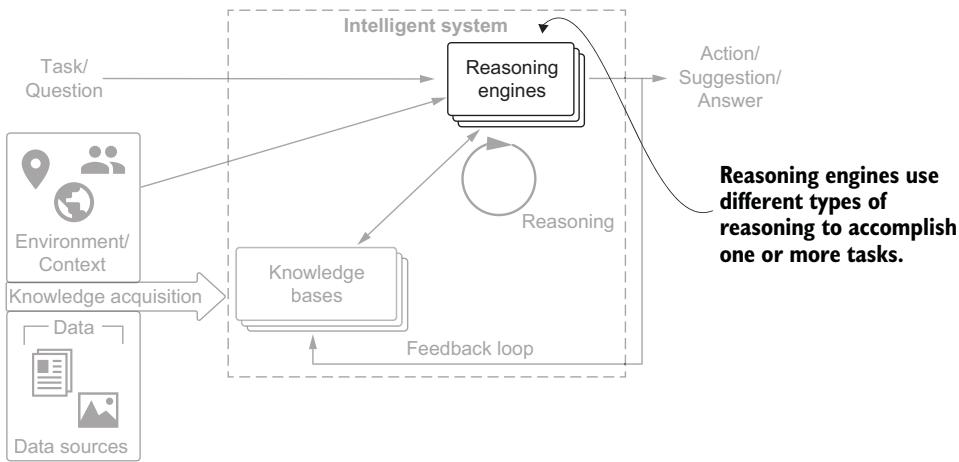

*그림 2.10 — 서로 다른 유형의 추론 전략을 지닌 여러 추론 엔진이, 지능형 시스템을 구현하는 데 필요한 과제들을 함께 수행한다. 그림 속 추론 엔진은 **일반형** 이다 — 한 가지 추론만 쓸 수도 있고 여러 전략을 조합할 수도 있다. 그림 2.4 와 비교해 보면 지식 베이스로 **되돌아가는** 화살표가 새로 생긴 것이 핵심이다.*

중요한 점은 이 엔진이 지식 베이스에서 **읽기만 하는 게 아니라 거기에 다시 쓴다** 는 것이다. 그래서 순환이 생긴다.

| 단계 | 일어나는 일 |
| --- | --- |
| ① 추론 | 엔진이 지식 베이스를 읽어 조치 또는 제안을 만든다 |
| ② 영향 | 그 조치가 환경에 영향을 준다 |
| ③ 관찰 | 변화한 환경이 새로운 관찰을 만들어 낸다 |
| ④ 축적 | 엔진이 관찰을 처리해 새 지식을 지식 베이스에 쌓는다 |
| ⑤ 반복 | 쌓인 지식이 다음 조치·제안을 이끈다 |

이 **피드백 루프(feedback loop)** 가 반복적 과정을 만들고, 그 안에서 시스템은 환경 변화에 대응하는 능력을 끊임없이 향상시킨다. 2.2.1 절의 정의 — "사용자와의 상호작용을 관찰함으로써 스스로 개선되는 시스템" — 가 아키텍처로 구현된 모습이 바로 이것이다.

#### 2.5.1 순수 연역적 추론 엔진의 한계 — 완벽한 지식 베이스라는 비현실적 전제

2.2 절의 의료 시나리오로 돌아가자. 한 환자가 가상의 의사, 즉 우리의 지능형 시스템을 찾아왔다. 시스템은 병을 진단하고 치료 방향을 제안하기 위해 일련의 조치(의학 검사·치료·질문)를 제안해야 한다.

이 조치의 순서는 지식 베이스로 계산된다. 그 지식 베이스에 담겨야 하는 것은 세 가지다.

| 담아야 할 것 | 예 |
| --- | --- |
| 가능한 조치들의 **비용과 결과** | 이 검사는 얼마나 비싸고 무엇을 알려주는가 |
| 질병과 증상 사이의 **확률적 관계** | 이 증상이 있을 때 이 질병일 가능성 |
| 환자의 **선호** | 침습적 검사를 원하는가 |

이 세 가지가 전부 부호화되어 있다면 **연역적 추론기(deductive reasoner)** 는 최적의 조치를 논리적으로 이끌어낼 수 있다. 그리고 이런 이상적 시나리오에서는 연역적 추론기가 다른 어떤 방법보다 뛰어나다. 답이 논리적으로 보증되기 때문이다.

**문제는 "이상적"이라는 단서에 있다.** 연역적 추론의 큰 한계는 매우 완전하고 정확한 지식 베이스를 요구한다는 점이고, 그런 지식 베이스는 현실에서 좀처럼 구하기 어렵다. 의료 도메인에서 "모든 증상-질병 확률"과 "모든 검사의 비용과 결과"가 빠짐없이 정리된 데이터베이스는 존재하지 않는다.

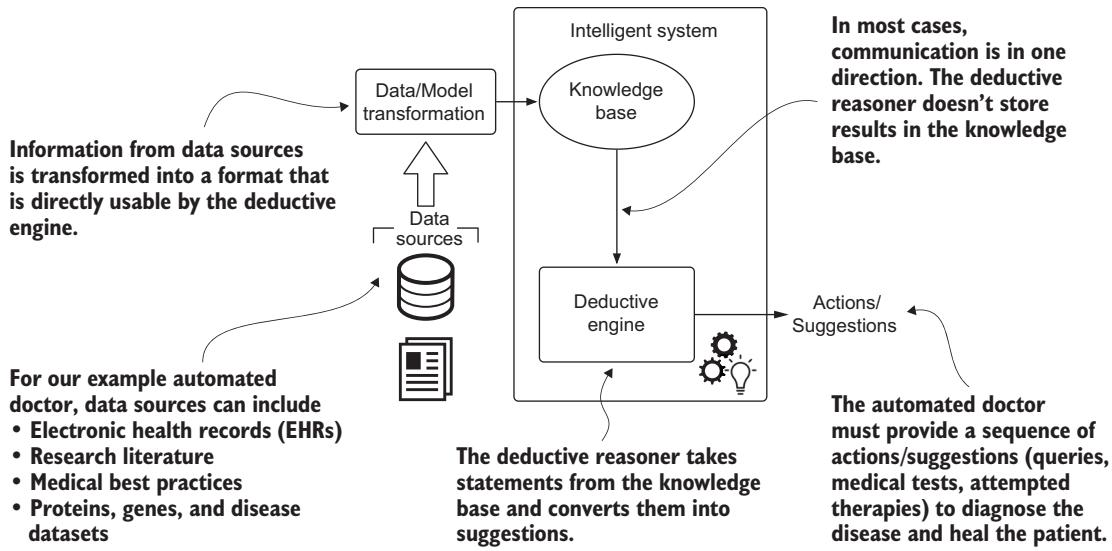

*그림 2.11 — 연역적 추론기. 지식 베이스는 데이터 소스를 **변환** 해 만들어지고, 추론기는 지식 베이스의 일부에 적용되는 논리적 진술을 사용해 행동하거나 제안한다. 변환이 단순하다는 점(다음 그림 2.12 와의 차이)에 주목하라 — 대신 그 단순함의 대가로 지식 베이스가 완전해야 한다.*

> **저장소 파일 참고** — 이 절의 "가상 의사" 시나리오와 주제가 통하는 프롬프트가 저장소에 있다. [`listings/2.1 - ChatGPT example Prompt`](./listings/2.1%20-%20ChatGPT%20example%20Prompt) 은 두통·건망증·언어 장애를 호소하는 환자에 대해 "당신은 가상의 의사"라고 지시하며 권고를 요구한다. **다만 이 프롬프트는 최종 출간본에 번호 붙은 리스팅으로 실려 있지 않다** (MEAP 잔여물이다). 위 코드 셀에서 원문을 확인할 수 있고, 이 노트북은 이것을 책 리스팅으로 취급하지 않는다. 참고로 이 프롬프트는 실제 증상에 대한 의학적 권고를 요구하므로, 4장 노트북이 임상 프롬프트(책 4.23)를 다룬 원칙 — **출력은 가설로만 다루고 임상 판단으로 쓰지 않는다** — 이 여기에도 그대로 적용된다.

#### 2.5.2 귀납적 추론과 ML 활용하기 — 불확실성 아래에서의 일반화

ML 이 구동하는 귀납적 추론은 순수 연역의 한계 중 일부를 해결한다. 두 가지 방식이다.

| 강화 | 내용 |
| --- | --- |
| **지식 베이스 확장** | 관련 온톨로지와 관계를 학습·구축해 더 넓은 범위의 사례를 다루게 한다 |
| **불확실성 아래의 추론** | 불완전한 데이터로부터 일반화해, 모든 정보가 갖춰지지 않아도 예측을 내놓게 한다 |

작동 방식은 두 단계다.

1. **원시 데이터를 구조화된 형식으로 변환한다** — 흔히 ML 알고리즘의 도움을 받는다. 예를 들어 LLM 이 구동하는 **자연어 처리(NLP)** 는 비구조화 텍스트를 지식 베이스에 통합할 수 있는 구조화된 데이터로 바꾼다. 이 단계가 **KG 를 생성하거나 확장** 하는 데 기여한다. 연구 논문·보고서 같은 텍스트 소스에서 개체와 관계를 추출하는 일이 여기 해당한다.

2. **그 지식을 사용해 예측을 수행한다** — 확보된 관찰들로부터 패턴을 추상화해 예측하거나 조치를 생성한다.

1번이 이 책 5\~8장의 주제이고(비정형 데이터에서 KG 만들기), 2번이 9\~12장의 주제다(그래프 위의 ML).

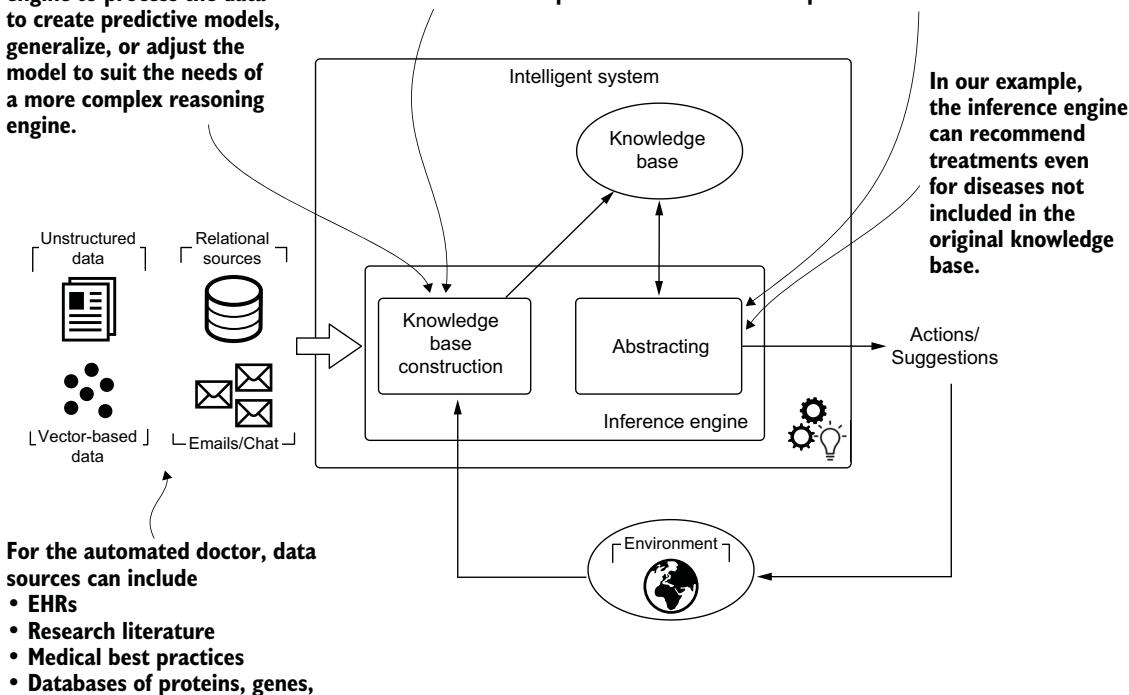

*그림 2.12 — 귀납적 추론기. 그림 2.11 과 결정적으로 다른 점은 지식 베이스 구성이 **단순한 변환이 아니라는 것** 이다. 대신 이 추론 엔진은 지식 베이스로부터 추상화할 수 있어, 가능한 모든 정보가 갖춰지지 않아도 행동하거나 제안할 수 있다. 그림에 단백질·유전자·질병 데이터베이스가 소스로 등장하는데, 이것이 4장에서 실제로 통합할 소스들이다.*

이 방식에도 대가가 있다. **전통적 ML 에서는 지식 베이스에서 특징(feature)을 수동으로 골라 예측 모델을 학습시켜야 하는 경우가 많다.** 지루한 작업이고, 복잡한 도메인에서는 때때로 실현 불가능하다. 10장(수동·반자동 그래프 특징 공학)과 11장(그래프 표현 학습)이 정확히 이 문장에서 출발한다 — 특징을 손으로 고르는 대신 학습으로 얻으려는 시도다.

#### 2.5.3 추론 엔진에서 LLM 의 역할 — 지식의 빈틈을 메우는 확률적 추론

앞의 두 절이 연역과 귀납의 자리를 정했다면, 여기서는 **LLM 이 앉을 자리** 를 정한다.

순수 연역 시스템은 완전한 지식 베이스와 명시적 규칙을 요구한다. LLM 은 다르다. **결정적인 정보가 빠져 있어도 확률적 추론으로 맥락에 맞는 제안을 만들어낼 수 있다.**

구체적 장면으로 보자. 어떤 환자가 스트레스에서 심각한 신경학적 질환까지 무엇이든 시사할 수 있는 **비특이적 증상** 을 호소하며 찾아왔다. 전통적 연역 추론은 이렇게 모호한 양상에, 특히 환자 기록이 불완전할 때 애를 먹는다. 반면 LLM 은 방대한 의학 문헌에서 배운 패턴을 끌어와 **여러 진단 가능성을 동시에 평가** 할 수 있다.

LLM 의 강점은 **불확실성을 안고 확률적으로 추론하는 능력** 이다. 확보된 데이터를 바탕으로 서로 다른 질환의 가능성을 저울질하고, 하나의 확정적인 답 대신 **우선순위가 매겨진 진단 접근법** 을 권고할 수 있다.

이 능력 덕분에 LLM 은 순수 연역이라면 멈춰 버릴 **지식의 빈틈** 을 메운다. KG 기반 추론 엔진과 통합되면 LLM 은 모호한 입력을 해석하고 불확실성을 감안한 섬세한 권고를 제공하는 **추론 계층** 으로 작동한다. 이 하이브리드 접근이야말로 정보가 흔히 불완전하고 불확실한 실제 환경에서 IAS 가 기능하게 하는 조건이다.

여기서 2.4 절과의 균형을 놓치면 안 된다. 2.4 절은 LLM 이 익숙한 패턴으로 미끄러지는 장면을 보여 줬고, 2.5.3 절은 같은 성질이 **빈틈을 메우는 능력** 이기도 하다고 말한다. 둘은 모순이 아니라 **같은 메커니즘의 양면** 이다. 그래서 설계의 관건은 LLM 을 쓰느냐 마느냐가 아니라, 그 출력을 검증할 명시적 근거(KG)를 옆에 두었느냐다.


---
### 2.6 IAS에 대한 KG 접근법 — 상향식의 함정과 목적 주도 방식

앞의 다섯 절이 **무엇을 지을지** 를 정했다면, 마지막 절은 **어떤 순서로 지을지** 를 정한다. 이 절이 이 장에서 가장 실무적이고, 저자들의 어조도 여기서 가장 단호하다.

"KG 는 IAS 개발에서 어디에 자리 잡는가?" 짧은 답은 **모든 곳** 이다. 최근 몇 년간 학계와 산업계는 KG 를 구조화된 인간 지식의 한 형태로 폭넓게 활용해 왔고, 그 위에서 통찰을 끌어내는 추론·분석 알고리즘도 여럿 고안됐다.

발상 자체는 새롭지 않다. **Stokman 과 de Vries** 는 지식 기반 시스템으로 "전문 지식의 범위가 제한된 전문 사용자에게 조언하는 컴퓨터 프로그램"을 만들 수 있으리라 일찍이 내다봤고, 이렇게 적었다.

> "지식을 그래프로 구조화하는 일은, 서로 다른 소스의 지식을 통합하는 지식 기반 시스템을 구축하는 것으로 볼 수 있다."

최근에는 KG 가 분산된 데이터 소스들을 **하나의 연결된 진실의 원천** 으로 합치는 표준 접근이 되었고, 생성형 AI 와 LLM 의 등장 이후로는 **환각(hallucination) 완화** 와 **최신 데이터 제공** 이라는 이점이 더해졌다.

#### 함정 — KG 를 "집계자"로만 보는 것

그런데 저자들은 바로 여기서 제동을 건다. **KG 를 단지 지식의 집계자(aggregator)로만 보는 것은, 애초에 KG 를 도입한 목표 — 지능형 시스템을 짓는 것 — 를 놓치는 일이다.**

이렇게 데이터부터 쌓아 올리는 방식이 **상향식(bottom-up) 접근법** 이다. 순서는 이렇다.

1. 여러 소스에서 데이터를 가져온다
2. 하나의 진실의 원천으로 통합한다
3. 발견(discovery) 과정을 개시한다
4. **최종 사용자가 무엇을 찾는지에 대한 아무런 생각 없이, 데이터가 알아서 이야기를 들려주기를 기대한다**

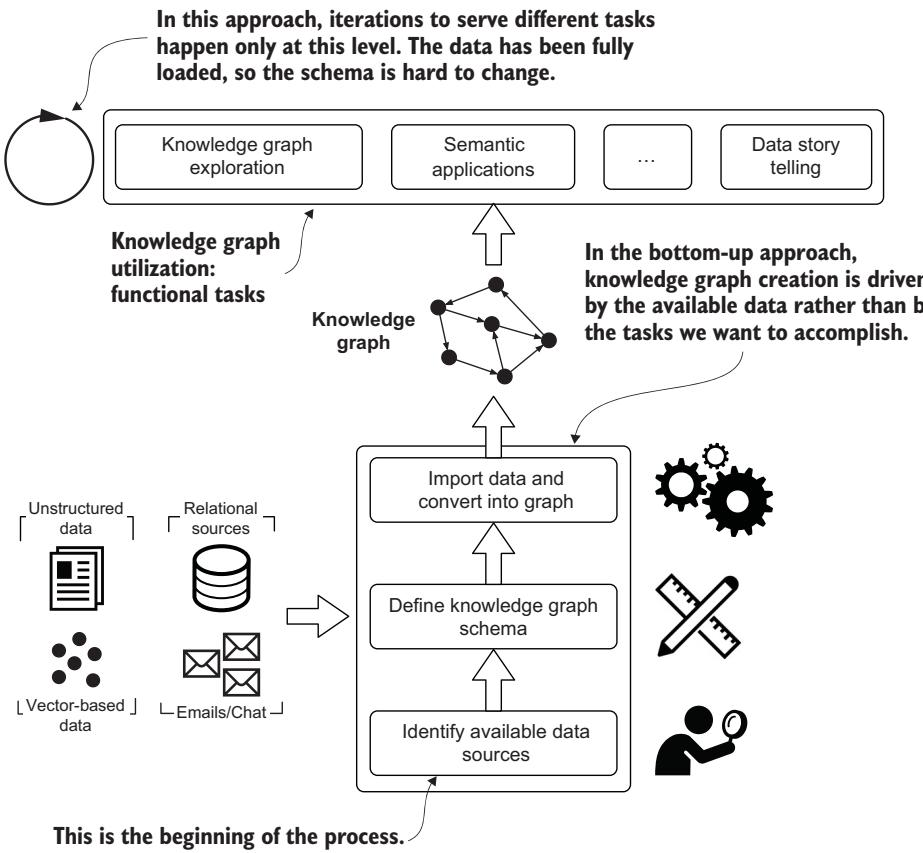

*그림 2.13 — KG 생성의 상향식 접근법. 달성하려는 **기능적 과제** 를 먼저 고려하는 대신 모든 데이터를 가져오는 데서 시작한다. 화살표가 데이터에서 출발해 한 방향으로만 흐르는 것이 이 그림의 문제다 — 어디서 멈춰야 하는지를 정해 주는 것이 아무것도 없다.*

저자들의 경험상 이 접근은 **흔히 KG 도입의 실패로 이어진다.** 이유는 세 가지다.

| 실패 요인 | 왜 문제인가 |
| --- | --- |
| 데이터 소스가 너무 많다 | 저마다 구조와 식별자가 다르다 |
| 정규화 비용이 크다 | 하나의 동질적 구조로 만드는 데 상당한 노력이 든다 |
| 대부분이 무관하다 | 내용의 상당 부분은 특정 과제에만 해당해 전역적 사고에는 관련이 없다 |

세 번째가 가장 뼈아프다. **비용은 전부 치르고 쓰이지 않는다.** 그리고 "언젠가 쓸지도 모른다"는 이유로 넣은 데이터는 검증 대상도 되지 못한다.

#### 처방 — 목적 주도 접근법과 CRISP-DM

지능적 에이전트를 개발하려면 지식을(우리 경우 KG 로) **효과적이고, 도메인의 내재적 복잡성을 포착·처리할 수 있는 방식** 으로 표현해야 한다. 그리고 이 접근은 **확보된 데이터가 아니라 비즈니스 목표에 의해 추동되어야 한다.**

저자들은 정립된 ML 프로젝트 방법론인 **CRISP-DM** 을 기반으로 KG 구축의 **목적 주도(purpose-driven) 접근법** 을 제시한다.

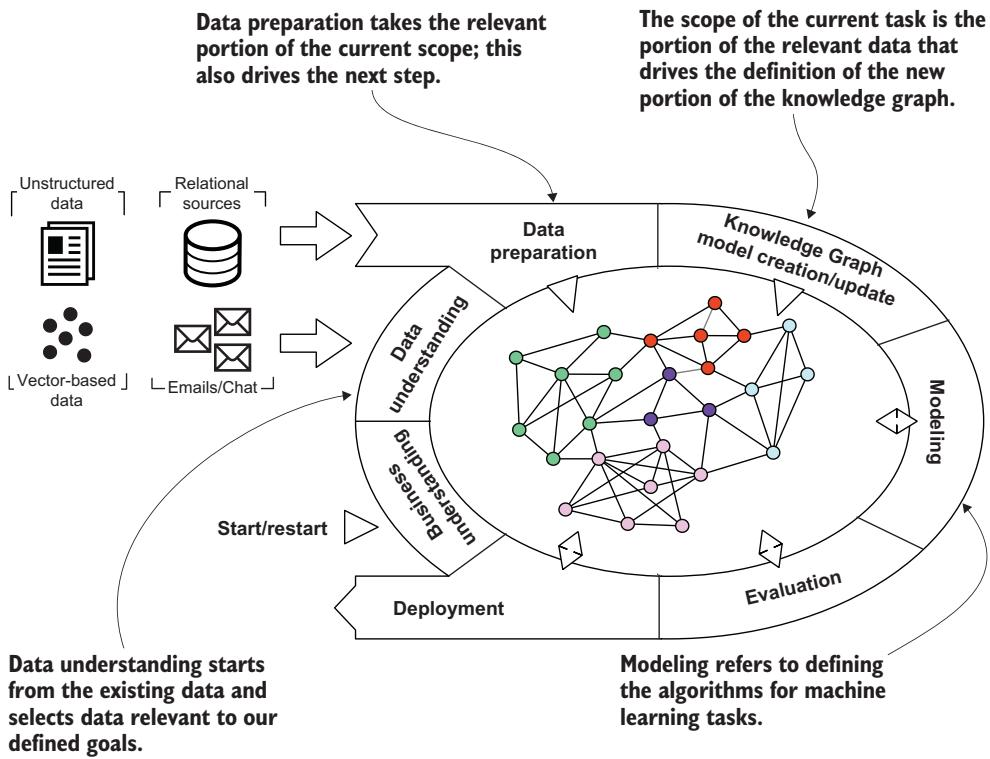

*그림 2.14 — KG 플랫폼에 적용한, 재해석된 CRISP-DM. KG 가 지능형 시스템의 지식 베이스 모델로 쓰이며 과정의 **중심** 에 놓인다. 그림 2.13 과 달리 순환이고, 출발점이 데이터가 아니라 **비즈니스 이해** 다. 3장 노트북의 절 구성이 이 그림을 그대로 따른다.*

| 단계 | 하는 일 | KG·LLM 의 역할 |
| --- | --- | --- |
| **비즈니스 이해** | 모든 것이 여기서 출발한다. 달성할 목표를 정한다 | — |
| **데이터 이해** | 목표가 이끄는 대로, 확보 가능한 모든 소스를 무작정 가져오는 대신 **필요한 특정 부분** 에 집중한다 | 이 단계가 KG 의 내용과 구조에 대한 요구사항을 결정한다 |
| **습득 / 데이터 준비** | 필요한 데이터를 복사·변환해 KG 로 옮긴다 | **LLM** 이 비구조화 데이터에서 개체·관계를 추출하고, 감성 분석·주제 식별 같은 일반적 이해를 제공한다 |
| **모델링** | 구체적 목표에 도달하기 위해 하나 이상의 알고리즘을 사용·시험한다 | **LLM** 이 KG 위에서 추론해 사용자 질문을 이해하고 자연어로 답한다 |
| **평가** | 결과를 평가한다 | 산출물: 알고리즘 집합 · 학습되거나 사전 학습된 모델 집합 · 시험 내용과 모델 품질을 기술한 보고서 |
| **배포** | 그래프 스키마·모델, 수집·후처리 파이프라인, 알고리즘, 예측 모델을 하나의 제품으로 통합해 배포한다 | — |

이 맥락에서 KG 는 **자족적이고(self-sufficient), 도메인 특화되며, 맞춤 설정 가능한 진실의 원천** 을 나타낸다. 원본 시스템을 대체하는 것이 아니라 필요한 데이터를 복사하고 변환해 담는다는 뜻이다.

> **정의** **예측 모델(predictive model)** 이란, 관심 있는 미지의 값 — 목표값(target) — 을 추정하기 위한 공식이다. 훈련 데이터셋에 대한 학습 과정의 결과를 효율적인 형식으로 나타낸 것이며, 실제 예측을 수행하기 위해 이 모델에 접근한다.

#### 두 번째 라운드 — 빈 KG 에서 시작하지 않는다

배포가 끝나면 새 라운드가 시작되는데, 이번에는 **빈 KG 에서 출발하지 않는다.** 두 번째 라운드는 **차이(difference)와 확장(extension)** 의 방식으로 작업하며, 이전 반복의 결과가 훼손되지 않도록 보장한다.

이것을 가능하게 하는 것이 그래프의 **스키마리스** 성질이다.

> **정의** **스키마리스(schemaless)** 란, 데이터 항목이 어떻게 형식화되고 서로 어떻게 관련되는지에 대한 제약이 더 적거나 전혀 없이 데이터를 저장할 수 있는 유연성을 가리킨다. 그래프 데이터베이스는 그 요소(노드와 관계)와 속성이 사실상 무엇이든 저장할 수 있으므로 일반적으로 스키마리스로 간주된다.

기존 데이터와 기능을 손상시키지 않으면서 **새로운 노드 유형과 관계 유형을 덧붙일 수 있다** 는 것이 핵심이다. 2.2.1 절의 "진화하는 지식 베이스"라는 요구가 기술적으로 성립하는 근거가 바로 이 성질이다. 스키마를 미리 고정하는 저장 기술이었다면 두 번째 라운드마다 마이그레이션이 필요했을 것이다.

다만 스키마리스가 "스키마를 쓰지 않는다"는 뜻은 아니다. 저자들은 이 책에서 시나리오와 사용 사례 사이의 과정을 이끌기 위해 **스키마를 자주 사용한다** 고 밝힌다. 그 스키마들은 여러 용도로 재활용되고, 각 단계가 과정이 실제로 어떻게 작동하는지 보여 주는 예시로 강조된다. 즉 **강제되지 않을 뿐 설계는 한다.**


---
## 요약

해설판이 정리한 이 장의 핵심 여섯 가지다.

- 지능은 근본적으로 **지식을 습득하고 적용하는 것** 이며, 그래서 **지식 표현** 과 **추론** 이 지능형 시스템 아키텍처의 핵심 구성 요소가 된다

- 지능형 시스템은 독립적으로 행동하는 **자율 시스템** 과 인간의 의사결정을 지원하는 **자문 시스템(IAS)** 으로 분류된다. 이 책은 IAS 를 택한다

- 지식 습득 방식이 KG 와 LLM 사이에서 갈린다. KG 는 도메인 전문성을 요구하지만 **해석 가능성** 을 주는 명시적·구조화된 표현을 쓰고, LLM 은 언어 이해를 포착하지만 **투명성이 없는** 암묵적 통계 패턴을 쓴다

- 하이브리드 시스템은 둘의 **상호 보완적 강점** 을 활용한다. KG 는 구조화된 추론과 명시적 지식을, LLM 은 모호성·맥락·자연어 이해를 담당한다

- LLM 은 **지식의 빈틈을 메우고** 맥락적 해석을 제공해 추론 엔진을 강화하며, 이를 통해 지능형 시스템이 불완전하거나 모호한 정보 속에서도 더 견고해진다

- 비즈니스 목표에서 출발하는 **목적 주도 KG 개발** 이, 흔히 프로젝트 실패로 이어지는 **상향식 데이터 통합** 전략보다 효과적이다

### 이 장이 제시한 구조와 그 근거

2장은 개념 장이라 실행해 얻은 수치가 없다. 대신 이 장이 내린 **배치 결정과 그 근거** 를 정리한다. 3장 이후에 "왜 여기서 이 기술을 쓰지"라는 질문이 생기면 이 표로 돌아오면 된다.

| 시스템의 자리 | 이 장이 배정한 담당 | 그렇게 정한 근거 | 근거 절 |
| --- | --- | --- | --- |
| 시스템의 종류 | **IAS**(자문) — 제안하되 실행하지 않는다 | IAS 가 요구하는 의사결정 지원·맥락 인식·상호작용이 KG 의 강점과 겹친다. 최종 결정은 사람이 내린다 | 2.2.2 |
| 지식 베이스의 출처 | **정립된 소스** — 연구 논문·기존 온톨로지·구조화 데이터 | 일반 상식이 아니라 전문가가 다듬은 도메인 특화 이해가 필요하다 | 2.2.3 |
| 지식 표현 (핵심) | **KG** — 명시적 노드·관계·속성 | 사람·기계가 직접 해석할 수 있고, 노드/관계 추가·삭제·수정만으로 갱신된다 | 2.3 |
| 비정형 소스의 지식화 | **LLM** — 개체·관계 추출, 감성·주제 식별 | 텍스트를 다루는 능력이 본질적이고, 광범위한 데이터 준비를 요구하지 않는다 | 2.3 · 2.6 |
| 규칙 기반·정밀 추론 | **KG** | 연역이 성립하려면 명시적이고 검증 가능한 전제가 있어야 한다 | 2.4 · 2.5.1 |
| 모호·불완전 정보 위의 추론 | **LLM** | 결정적 정보가 빠져도 확률적으로 가능성을 저울질해 우선순위를 제시한다 | 2.5.3 |
| 일반화·예측 | **ML/귀납적 추론기** (그래프 위에서) | 완전한 지식 베이스라는 연역의 전제가 현실에서 성립하지 않는다 | 2.5.2 |
| 지식의 진화 | **피드백 루프** — 추론 엔진이 지식 베이스에 다시 쓴다 | 정의상 지능형 시스템은 상호작용을 관찰해 스스로 개선되어야 한다 | 2.2.1 · 2.5 |
| 구축 순서 | **목적 주도** — 비즈니스 이해 → 데이터 이해 → KG | 상향식은 정규화 비용을 다 치르고도 대부분이 과제와 무관해 실패한다 | 2.6 |
| 확장 방식 | **차이와 확장** — 스키마리스 그래프에 유형을 덧붙인다 | 이전 반복의 결과를 훼손하지 않고 두 번째 라운드를 시작할 수 있다 | 2.6 |

### 이 장에서 확인한 사실

| 항목 | 확인한 값 | 근거 |
| --- | --- | --- |
| 책 2장의 번호 붙은 리스팅 수 | **1개** (Listing 2.1) | 원서 원문 md 에서 `Listing 2.N` 패턴을 추출 |
| 그 리스팅의 저장소 파일 | `2.3 - Prompt for checking reasoning capabilities` | `study.toml` 의 `[mapping.listings.ch02]` |
| 저장소 `listings/` 파일 수 | 2개 (하나는 책에 대응 없음) | `2.1 - ChatGPT example Prompt` 는 MEAP 잔여 |
| 이 장에 필요한 외부 서비스 | **없음** | Cypher·데이터셋·API 키가 모두 불필요 |
| 저자들이 테스트한 모델 | Claude 3.5 Sonnet (\~2024) | 저자 주석 |
| 리스팅 2.1 재측정 (2026-07-25) | `gpt-5.4-mini`·`gpt-5.4` **둘 다 정답(1회)** | 책이 관찰한 실패가 재현되지 않았다 |
| 그림 | 2.1\~2.14 (14장 전부 수록) | 원서 원문 md 의 `Figure 2.N` 캡션 |

> **재현성 주의** — 리스팅 2.1 의 결과는 **모델과 시점에 따라 달라진다.** 저자들도 같은 경고를 남겼고, 실제로 2026-07-25 재측정에서 두 모델 모두 정답을 냈다 (2.4 절 「2026년 재측정」 참고). 그림 2.9 는 2024년 Claude 3.5 Sonnet 의 응답이다. **재현되지 않는다는 것이 이 장의 논점을 뒤집지는 않는다** — 근거는 이 프롬프트 하나가 아니라 Wu 등의 11개 과제 결과이고, 이 예시가 출간 후 학습 데이터에 들어갔을 가능성도 배제할 수 없다. 확인할 것은 정답 여부가 아니라 모델이 문제 서술을 읽는지다. 이 노트북이 API 호출을 기본값으로 두지 않는 이유도 여기에 있다.

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 지식 그래프 (Knowledge Graph, KG) | 검증된 사실을 노드(개체)와 간선(관계)으로 **명시적** 으로 표현한 데이터 구조. 사람과 기계 모두 직접 해석·수정 가능 |
| 대규모 언어 모델 (Large Language Model, LLM) | 방대한 텍스트를 학습해 언어를 이해·생성하는 모델. 지식을 벡터 공간의 매개변수로 **암묵적** 으로 저장하며 불투명하다 |
| 지식 표현 (knowledge representation) | AI 시스템이 도메인 정보를 구조화·부호화·전달하는 데 쓰는 "언어". 시스템의 능력과 한계를 좌우한다 |
| 추론 (reasoning) | 정보를 분석하고 규칙을 적용해 증거·전제로부터 결론을 이끌어내는 인지 과정 |
| 연역적 추론 (deductive reasoning) | 일반 전제 → 구체적·논리적 결론. 전제가 참이면 결론도 참 |
| 귀납적 추론 (inductive reasoning) | 구체적 관찰 → 폭넓은 일반화. 전제가 참이어도 결론이 거짓일 수 있다 |
| 지능형 시스템 (intelligent system) | 사용자를 AI·ML 과 연결해 의미 있는 목표를 달성하게 하고, 상호작용 관찰로 스스로 개선되는 시스템 (Hulten) |
| 지능형 자율 시스템 (intelligent autonomous system) | 사용자를 대신해 독립적으로 판단·실행하는 시스템 (예: 자율주행차) |
| 지능형 자문 시스템 (Intelligent Advisory System, IAS) | 정보와 권고를 제공하되 최종 결정은 사용자가 내리는 시스템. 이 책의 주된 초점 |
| 지식 습득 (knowledge acquisition) | 데이터 소스·환경·전문가로부터 정보를 수집해 구조화된 지식으로 변환하는 과정 |
| 도메인 전문가 (domain expert) | 데이터의 의미와 개체 간 관계를 이해하도록 돕고 결과를 평가하는 전문가 |
| 개체 (entity) | KG 에서 노드로 표현되는 대상. 개체 간 관계는 간선으로 표현된다 |
| 피드백 루프 (feedback loop) | 조치 → 환경 변화 → 새 관찰 → 새 지식 → 새 조치로 이어지는 반복적 개선 순환 |
| 자연어 처리 (Natural Language Processing, NLP) | 비구조화 텍스트를 구조화된 데이터로 변환하는 기술. LLM 이 구동한다 |
| 예측 모델 (predictive model) | 미지의 목표값(target)을 추정하는 공식. 훈련 데이터에 대한 학습 결과를 효율적 형식으로 나타낸 것 |
| 스키마리스 (schemaless) | 데이터 형식·관계에 제약이 적거나 없는 저장 방식의 유연성. 그래프 DB 의 특성 |
| 상향식 접근법 (bottom-up approach) | 목적을 먼저 정하지 않고 모든 데이터부터 통합하는 KG 구축 방식. 흔히 실패로 이어진다 |
| 목적 주도 접근법 (purpose-driven approach) | 비즈니스 목표가 데이터 이해와 KG 구조를 이끄는 구축 방식 |
| CRISP-DM | 정립된 ML·데이터 마이닝 프로젝트 방법론. 목적 주도 KG 구축의 토대 |
| 환각 (hallucination) | LLM 이 사실이 아닌 내용을 그럴듯하게 지어내는 현상. KG 가 이를 완화할 수 있다 |
| 반사실적 과제 (counterfactual task) | 잘 알려진 과제의 기본 설정을 벗어나게 비튼 변형. 암기와 추론을 분리해 낸다 |

### 참고 링크

- [교재 2장 해설판 (한국어)](../../02_intelligent_systems_a_hybrid_approach_ko_explained.md)

- [교재 2장 원서 원문 (영어)](../../02_intelligent_systems_a_hybrid_approach.md)

- [1장 해설판 — KG 와 LLM 의 조합이 왜 필요한가](../../../chapter_01_knowledge_graphs_and_llms_a_killer_combination/01_knowledge_graphs_and_llms_a_killer_combination_ko_explained.md)

- [원서 저장소 chapters/ch02](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch02)

- [Manning — Knowledge Graphs and LLMs in Action](https://www.manning.com/books/knowledge-graphs-and-llms-in-action)

- [Wu 등, *Reasoning or Reciting? Exploring the Capabilities and Limitations of Language Models Through Counterfactual Tasks* (arXiv 2307.02477)](https://arxiv.org/abs/2307.02477) — 2.4 절이 인용한 11개 과제 반사실적 평가

- [CRISP-DM 개요 (Wikipedia)](https://en.wikipedia.org/wiki/Cross-industry_standard_process_for_data_mining) — 2.6 절 목적 주도 접근의 토대

### 다음 장으로

2장은 도면만 그렸다. **3장(저장소 [`ch03`](../../../chapter_03_create_your_first_knowledge_graph_from_ontologies/src/ch03))** 부터 이 도면의 칸을 실제로 채운다. [3장 노트북 열기](../../../chapter_03_create_your_first_knowledge_graph_from_ontologies/src/ch03/03_chapter_guide.ipynb)

3장이 채우는 칸은 이 장의 용어로 정확히 지목된다.

| 2장의 개념 | 3장에서의 구현 |
| --- | --- |
| 목적 주도 접근 (2.6, 그림 2.14) | 비즈니스 이해(임상의의 희귀 질환 진단)에서 출발해 필요한 데이터만 고른다 |
| 정립된 지식 베이스 (2.2.3) | 상식이 아니라 **HPO 온톨로지** 와 주석 파일을 소스로 쓴다 |
| 지식 표현의 선택 (2.1) | RDF 와 LPG 를 비교해 LPG 를 고른다 — "표현 방식이 능력과 한계를 좌우한다"의 실물 |
| 명시적 지식 습득 (2.3, 그림 2.6) | 형식이 다른 두 소스를 온톨로지를 기준 어휘 삼아 하나의 그래프로 합친다 |
| 연역적 추론 (2.5.1) | 질병 온톨로지 계층을 타고 올라가는 온톨로지 기반 추론 |

그리고 **3장부터는 Neo4j 가 필요하다.** 3장은 Community + `n10s` 플러그인, 4장은 Enterprise 다. 두 요구가 배타적이므로(그 이유는 3·4장 노트북의 실행 환경 절에 있다) 컨테이너를 분리해 전환하게 된다. 2장에서 아무것도 띄우지 않았던 것은 이 장이 개념 장이기 때문이지 준비를 미룬 것이 아니다.
